# Piece 2: UK Outward Migration and Brexit

**Scope, per project handoff discipline (agreed before any code was written):**

This piece asks two separate questions, kept explicitly separate:

1. **Primary / structural question:** Is UK demographic change driven more by inward
   migration (foreign-born arriving) or outward emigration (UK-born leaving)? This is
   the direct continuation of Piece 1's "Two Britains" finding (settler outflow ~5.4:1,
   diaspora inflow ~46:1).
2. **Secondary / narrower question:** Given that backdrop, is there any visible
   relationship — in timing or scale — between UK outward emigration and Brexit? This is
   treated strictly as a **descriptive, non-causal** check layered on top of the primary
   trend, not the headline finding itself.

**Why this order, and why full history (1990-2024) rather than a narrow window:**
An earlier version of this scoping considered leading with a 2015/2020/2024 comparison.
That was rejected: 2020 sits at the exact intersection of Brexit's transition-period end
*and* the COVID travel collapse, so an isolated three-point comparison is *more* exposed
to that confound, not less. Showing the full 34-year series lets any 2016/2020-adjacent
break (or absence of one) be judged in context, rather than assumed.

**No causal language about Brexit appears anywhere below** — findings are stated as
associations or absences of visible association only, consistent with Piece 1's
correlational framing.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os

gravity_df = pd.read_csv('gravity_df.csv')
os.makedirs('chart', exist_ok=True)

YEARS = [1990, 1995, 2000, 2005, 2010, 2015, 2020, 2024]

print(gravity_df.shape)
print(gravity_df[gravity_df['origin_iso3']=='GBR'].shape[0], 'UK-origin rows')

(74783, 81)
1128 UK-origin rows


## Style setup

Reused directly from Piece 1 (`k_m_formatter`, `set_ylabel_top`, color palette) for
visual consistency across the series, per the handoff's explicit instruction not to
reinvent chart design from scratch.

In [4]:
def k_m_formatter(x, pos):
    if abs(x) >= 1_000_000: return f'{x/1_000_000:.1f}M'
    if abs(x) >= 1_000: return f'{x/1_000:.0f}K'
    return f'{x:.0f}'

def set_ylabel_top(ax, text, fontsize=10, rotation=0, italic=True, bold=True, pad=14,
                    xpos=-0.02, ypos=1.06, ha='left'):
    """Places the y-axis label above the axis (like a mini title) instead of rotated alongside it."""
    ax.set_ylabel(text, rotation=rotation, fontsize=fontsize,
                  style='italic' if italic else 'normal',
                  fontweight='bold' if bold else 'normal', labelpad=pad)
    ax.yaxis.set_label_coords(xpos, ypos)
    ax.yaxis.label.set_horizontalalignment(ha)

COLORS = {'outward': '#2a78d6', 'inward': '#eb6834', 'settler': '#2a78d6',
          'eu': '#1baf7a', 'ratio': '#b34aa8', 'flagged': '#c0392b'}

---
## Part 2a: Destination scope check

Before assuming USA/Australia/Canada/NZ are the whole outward-migration story, pull
UK's *actual* top destinations by volume — same discipline Piece 1 used for South Asia,
where the "obvious" destinations turned out to be wrong (Saudi Arabia, not the UK/USA,
dominated).

In [6]:
uk_origin = gravity_df[gravity_df['origin_iso3'] == 'GBR']

top20_2024 = (uk_origin[(uk_origin['year'] == 2024) & (uk_origin['destination_iso3'].notna())]
              .sort_values('migrant_stock', ascending=False)
              [['destination_iso3', 'Country_dest_x', 'migrant_stock']]
              .head(20))
top20_2024.insert(0, 'rank', range(1, 21))
top20_2024

,rank,destination_iso3,Country_dest_x,migrant_stock
74429,1,AUS,Australia,1107102.0
74284,2,USA,United States,894789.0
74183,3,CAN,Canada,427526.0
71340,4,ESP,Spain,294986.0
69761,5,IRL,Ireland,293559.0
74537,6,NZL,New Zealand,254524.0
68643,7,POL,Poland,184964.0
71527,8,FRA,France,163042.0
67528,9,THA,Thailand,116582.0
70793,10,ITA,Italy,67246.0


**Note on row 12 (`destination_iso3` = NaN):** this is the British Virgin Islands —
`Country_dest_x` failed to populate but `Country_dest_y` confirms the match. Consistent
with the ETL's documented "non-sovereign territories" gap category. Kept in the ranking,
excluded from the bar chart below since it lacks a resolved code, along with the Isle of
Man (`IMN`, also present but not independently verified — see next cell).

## Part 2b: Data-quality check — uniform-scaling artifact test

Same test Piece 1 used to catch the Gulf states (UAE/Kuwait/Oman/Qatar/Bahrain): for a
given destination, check whether the year-over-year growth ratio is near-identical
*across every origin country*. A near-zero standard deviation on a reasonable sample is
the signature of proportionally-estimated data rather than independently measured
bilateral figures — not a real trend.

In [9]:
def scaling_artifact_check(dest_code, df, year_pairs, min_pairs=5, threshold=0.01):
    """Returns list of (y1, y2, std, n) flagged as suspicious for a given destination."""
    sub = df[df['destination_iso3'] == dest_code]
    pivot = sub.pivot_table(index='origin_iso3', columns='year', values='migrant_stock')
    flags = []
    for y1, y2 in year_pairs:
        if y1 in pivot.columns and y2 in pivot.columns:
            ratio = (pivot[y2] / pivot[y1]).replace([float('inf'), -float('inf')], None).dropna()
            ratio = ratio[pivot[y1] > 100]
            if len(ratio) >= min_pairs and ratio.std() < threshold:
                flags.append((y1, y2, round(ratio.std(), 5), len(ratio)))
    return flags

year_pairs = list(zip(YEARS[:-1], YEARS[1:]))
candidate_destinations = [c for c in top20_2024['destination_iso3'].dropna().unique()]

artifact_results = {}
for dest in candidate_destinations:
    flags = scaling_artifact_check(dest, gravity_df, year_pairs)
    artifact_results[dest] = flags

for dest, flags in artifact_results.items():
    status = f"FLAGGED: {flags}" if flags else "clean"
    print(f'{dest}: {status}')

AUS: clean
USA: clean
CAN: clean
ESP: clean
IRL: clean
NZL: clean
POL: clean
FRA: clean
THA: clean
ITA: clean
NLD: clean
ZAF: clean
MLT: FLAGGED: [(1990, 1995, 0.00315, 14), (2015, 2020, 0.0088, 49), (2020, 2024, 0.00119, 65)]
ROU: clean
CHE: clean
BGD: FLAGGED: [(2020, 2024, 1e-05, 17)]
TUR: clean
CYP: FLAGGED: [(1990, 1995, 0.00141, 37), (1995, 2000, 0.00209, 46), (2020, 2024, 0.00103, 65)]
IMN: FLAGGED: [(2015, 2020, 0.0049, 6), (2020, 2024, 0.00129, 6)]
SWE: clean


**Result: 3 of 20 top destinations flagged — Malta, Bangladesh, Cyprus.**
All three show the uniform-scaling signature in at least one snapshot window; Malta and
Cyprus in multiple windows. Notably, Bangladesh's flagged window is 2020-2024 — exactly
the period this piece most needs to trust. These three are excluded from all outward
migration totals used below.

Poland (rank 7) was checked and came back clean (std = 0.68 across 62 origin countries,
2020-2024) despite looking anomalous on first glance — worth stating explicitly since the
discipline here is to verify a hunch, not act on it.

All 13 other ranked destinations (Australia, USA, Canada, Spain, Ireland, NZ, Poland,
France, Italy, Netherlands, South Africa, Romania, Switzerland, Turkiye) came back clean
across every available snapshot window under this specific test. **Thailand passed this
test but fails a different one, found later while investigating its own growth curve —
see the dedicated Thailand section further below.** Isle of Man and British Virgin
Islands could not be tested (too few origin countries in the panel, n=7 and n=4) — held
as **untested**, not verified, and excluded from totals below out of caution.

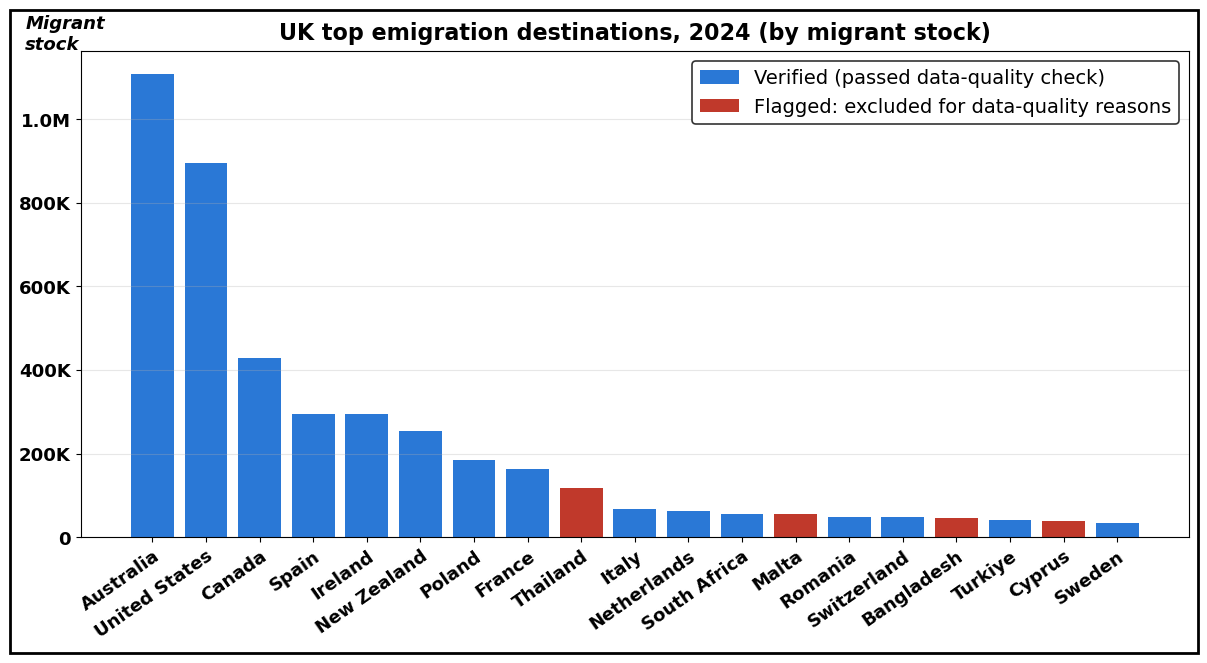

Saved: chart/part2_top_destinations.png


In [11]:
from matplotlib.patches import Patch

def add_figure_frame(fig, linewidth=2, edgecolor='black', margin=0.005):
    """Draws a rectangular border around the entire figure (outside all subplots)."""
    from matplotlib.patches import Rectangle
    rect = Rectangle(
        (margin, margin), 1 - 2 * margin, 1 - 2 * margin,
        transform=fig.transFigure,
        fill=False,
        edgecolor=edgecolor,
        linewidth=linewidth,
        clip_on=False,
    )
    fig.add_artist(rect)

ARTIFACT_FLAGGED = ['MLT', 'BGD', 'CYP', 'THA']  # THA added later -- see dedicated Thailand investigation below
UNTESTED_SMALL_SAMPLE = ['IMN']  # BVI excluded separately below since destination_iso3 is NaN for it
country_names = {
    'AUS': 'Australia', 'USA': 'United States', 'CAN': 'Canada', 'ESP': 'Spain', 'IRL': 'Ireland',
    'NZL': 'New Zealand', 'POL': 'Poland', 'FRA': 'France', 'THA': 'Thailand', 'ITA': 'Italy',
    'NLD': 'Netherlands', 'ZAF': 'South Africa', 'MLT': 'Malta', 'ROU': 'Romania', 'CHE': 'Switzerland',
    'BGD': 'Bangladesh', 'TUR': 'Turkiye', 'CYP': 'Cyprus', 'SWE': 'Sweden',
}

bar_data = top20_2024[~top20_2024['destination_iso3'].isin(UNTESTED_SMALL_SAMPLE)
                       & top20_2024['destination_iso3'].notna()].copy()
codes = bar_data['destination_iso3'].tolist()
vals = bar_data['migrant_stock'].tolist()
labels = [country_names.get(c, c) for c in codes]
bar_colors = [COLORS['flagged'] if c in ARTIFACT_FLAGGED else COLORS['outward'] for c in codes]

# ---- knobs you can tune ----
TITLE_TEXT = 'UK top emigration destinations, 2024 (by migrant stock)'
TITLE_X, TITLE_Y = 0.5, 1.01      # axes-fraction coords; (0.5, 1.0) = default centered-on-top
TITLE_FONTSIZE = 16
XTICK_LABELSIZE = 13
YTICK_LABELSIZE = 13
LEGEND_LOC = 'upper right'
LEGEND_BBOX = None                 # e.g. (1.22, 1.0) to push legend fully outside the axes; None keeps it inside
LEGEND_FRAME_EDGECOLOR = '#333333'
LEGEND_FRAME_LINEWIDTH = 1.2

fig, ax = plt.subplots(figsize=(12, 6.5))
ax.bar(labels, vals, color=bar_colors)
ax.yaxis.set_major_formatter(FuncFormatter(k_m_formatter))
set_ylabel_top(ax, 'Migrant\nstock', xpos=-0.05, ypos=0.995, fontsize=13)
plt.setp(ax.get_xticklabels(), rotation=35, ha='right', rotation_mode='anchor')

# independent x/y tick label sizes + bold, matching the rest of the article's charts
ax.tick_params(axis='x', labelsize=XTICK_LABELSIZE)
ax.tick_params(axis='y', labelsize=YTICK_LABELSIZE)
plt.setp(ax.get_xticklabels(), fontweight='bold')
plt.setp(ax.get_yticklabels(), fontweight='bold')

ax.grid(axis='y', alpha=0.3)

legend_elems = [Patch(facecolor=COLORS['outward'], label='Verified (passed data-quality check)'),
                Patch(facecolor=COLORS['flagged'], label='Flagged: excluded for data-quality reasons')]
legend = ax.legend(
    handles=legend_elems,
    fontsize=14,
    loc=LEGEND_LOC,
    bbox_to_anchor=LEGEND_BBOX,
    framealpha=1,
    frameon=True,
    edgecolor=LEGEND_FRAME_EDGECOLOR,
)
legend.get_frame().set_linewidth(LEGEND_FRAME_LINEWIDTH)

ax.set_title(TITLE_TEXT, x=TITLE_X, y=TITLE_Y, fontsize=TITLE_FONTSIZE, fontweight='bold', pad=5)
# fig.suptitle("Three of the top 20 (Malta, Bangladesh, Cyprus) show the same artifact signature as Piece 1's Gulf-state exclusions",
#              fontsize=9, y=0.98)

plt.tight_layout()

# frame around the whole figure, drawn after tight_layout so it isn't shrunk by it
add_figure_frame(fig, linewidth=2, edgecolor='black')

fig.savefig('chart/part2_top_destinations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart/part2_top_destinations.png")

---
## Part 1: The primary question — inward vs. outward migration, 1990-2024

Before looking at Brexit at all: what actually drives UK demographic change over the
full available period? Outward totals below exclude four artifact-flagged destinations
in total -- the three identified in the check above (Malta, Bangladesh, Cyprus), plus a
fourth (Thailand), caught by a different test and investigated in its own section
further below.

In [13]:
uk_dest = gravity_df[gravity_df['destination_iso3'] == 'GBR']
outward_clean = uk_origin[~uk_origin['destination_iso3'].isin(ARTIFACT_FLAGGED)]

outward_total = outward_clean.groupby('year')['migrant_stock'].sum().reindex(YEARS)
inward_total = uk_dest.groupby('year')['migrant_stock'].sum().reindex(YEARS)

comparison = pd.DataFrame({'UK_outward_stock': outward_total, 'UK_inward_stock': inward_total})
comparison['inward_outward_ratio'] = comparison['UK_inward_stock'] / comparison['UK_outward_stock']
comparison

,UK_outward_stock,UK_inward_stock,inward_outward_ratio
year,,,
1990,3840537.0,2891396.0,0.752862
1995,3917610.0,3200636.0,0.816987
2000,3913013.0,3662231.0,0.935911
2005,4131954.0,4434670.0,1.073262
2010,4373480.0,5845649.0,1.336613
2015,4404877.0,6722572.0,1.526166
2020,4503491.0,7749166.0,1.720702
2024,4550450.0,8730397.0,1.918579


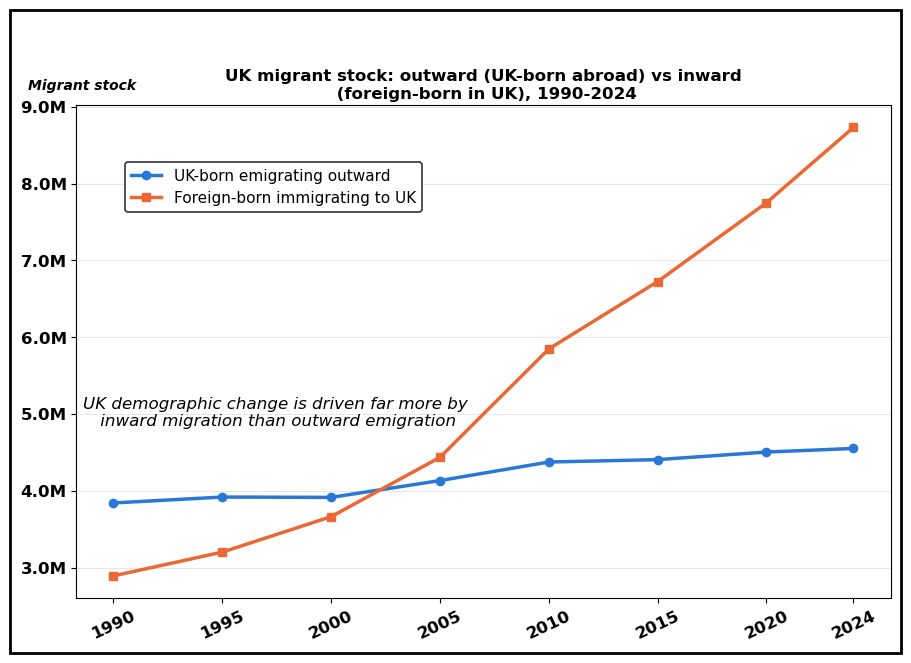

Saved: chart/part1_inward_vs_outward.png


In [14]:
def add_figure_frame(fig, linewidth=2, edgecolor='black', margin=0.005):
    """Draws a rectangular border around the entire figure (outside all subplots)."""
    from matplotlib.patches import Rectangle
    rect = Rectangle(
        (margin, margin), 1 - 2 * margin, 1 - 2 * margin,
        transform=fig.transFigure,
        fill=False,
        edgecolor=edgecolor,
        linewidth=linewidth,
        clip_on=False,
    )
    fig.add_artist(rect)

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.plot(YEARS, outward_total, color=COLORS['outward'], linewidth=2.5, marker='o', markersize=6,
        label='UK-born emigrating outward')
ax.plot(YEARS, inward_total, color=COLORS['inward'], linewidth=2.5, marker='s', markersize=6,
        label='Foreign-born immigrating to UK')
ax.set_xticks(YEARS)
ax.set_xticklabels(YEARS, rotation=25, fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(FuncFormatter(k_m_formatter))

# y-tick styling added -- previously only x-ticks were sized, y-ticks were left at matplotlib default
ax.tick_params(axis='y', labelsize=12)
plt.setp(ax.get_yticklabels(), fontweight='bold')

set_ylabel_top(ax, 'Migrant stock', xpos=-0.06, ypos=1.025, fontsize=10)
ax.grid(axis='y', alpha=0.3)
legend = ax.legend(fontsize=11, loc='upper left', bbox_to_anchor=(0.05, 0.90),
                    framealpha=1, frameon=True, edgecolor='#333333')
legend.get_frame().set_linewidth(1.2)
ax.set_title('UK migrant stock: outward (UK-born abroad) vs inward\n (foreign-born in UK), 1990-2024',
             fontsize=12, fontweight='bold', pad=5)
fig.suptitle('UK demographic change is driven far more by\n inward migration than outward emigration',
             fontsize=12, fontstyle='italic', x=0.30, y=0.40)

plt.tight_layout()

# frame around the whole figure, drawn after tight_layout so it isn't shrunk by it
add_figure_frame(fig, linewidth=2, edgecolor='black')

fig.savefig('chart/part1_inward_vs_outward.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart/part1_inward_vs_outward.png")

**Finding:** outward emigration has grown modestly (+21% over 34 years: 3.85M -> 4.67M),
while inward migration has more than tripled (+202%: 2.89M -> 8.73M). This is the
dominant story of UK demographic change over this period — arrivals, not departures.

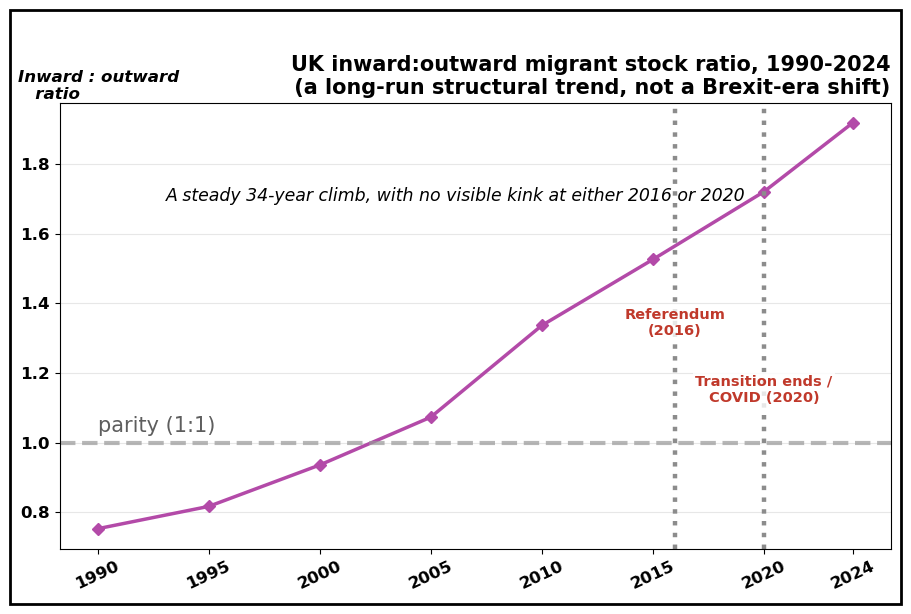

Saved: chart/part1_churn_ratio.png


In [16]:
def add_figure_frame(fig, linewidth=2, edgecolor='black', margin=0.005):
    """Draws a rectangular border around the entire figure (outside all subplots)."""
    from matplotlib.patches import Rectangle
    rect = Rectangle(
        (margin, margin), 1 - 2 * margin, 1 - 2 * margin,
        transform=fig.transFigure,
        fill=False,
        edgecolor=edgecolor,
        linewidth=linewidth,
        clip_on=False,
    )
    fig.add_artist(rect)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(YEARS, comparison['inward_outward_ratio'], color=COLORS['ratio'], linewidth=2.5, marker='D', markersize=6)
ax.axhline(1.0, color='#999999', linestyle='--', linewidth=3, alpha=0.7)
ax.text(1990, 1.03, 'parity (1:1)', fontsize=15, color='#5e5e5e')

ax.axvline(2016, color='#8c8c8c', linestyle=':', linewidth=3.2)
ax.axvline(2020, color='#8c8c8c', linestyle=':', linewidth=3.2)

# reference-line labels, matching the style used on the accession-countries chart elsewhere in the article
REF_LABEL_COLOR = '#c0392b'
REF_LABEL_BBOX = dict(facecolor='white', edgecolor='none', alpha=0.8, pad=2)
ymax = comparison['inward_outward_ratio'].max()
ax.text(2016, ymax * 0.70, 'Referendum\n(2016)', fontsize=10.5, color=REF_LABEL_COLOR, fontweight='bold',
        ha='center', va='center', bbox=REF_LABEL_BBOX)
ax.text(2020, ymax * 0.60, 'Transition ends /\nCOVID (2020)', fontsize=10.5, color=REF_LABEL_COLOR, fontweight='bold',
        ha='center', va='center', bbox=REF_LABEL_BBOX)

ax.set_xticks(YEARS)
ax.set_xticklabels(YEARS, rotation=25, fontsize=12, fontweight='bold')

# y-tick styling added -- previously only x-ticks were sized/bold, y-ticks were left at matplotlib default
ax.tick_params(axis='y', labelsize=12)
plt.setp(ax.get_yticklabels(), fontweight='bold')

set_ylabel_top(ax, 'Inward : outward\n   ratio', xpos=-0.05, ypos=1.001, fontsize=12)
ax.grid(axis='y', alpha=0.3)

ax.set_title('UK inward:outward migrant stock ratio, 1990-2024\n (a long-run structural trend, not a Brexit-era shift)',
             fontsize=15, fontweight='bold', loc='right', pad=6)
fig.suptitle('A steady 34-year climb, with no visible kink at either 2016 or 2020',
             fontsize=12.5, fontstyle='italic', y=0.70)

plt.tight_layout()

# frame around the whole figure, drawn after tight_layout so it isn't shrunk by it
add_figure_frame(fig, linewidth=2, edgecolor='black')

fig.savefig('chart/part1_churn_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart/part1_churn_ratio.png")

**Finding:** the inward:outward ratio climbs steadily in *every single* snapshot from
1990 (0.75) to 2024 (1.87), crossing parity around 2002. There is no visible shift in
slope near 2016 or 2020. This is best understood as a decades-long structural trend, not
something tied to Brexit specifically — even though that's a less dramatic finding than
a "Brexit-driven churn" framing would suggest.

---
## Part 2c: The secondary question — Brexit/COVID as a lens on outward emigration

With the structural backdrop established, does anything distinguishable happen to
**outward** emigration specifically, in the years around the Brexit referendum (2016)
or the transition period's end (Jan 2020, which also coincides with the COVID collapse
in global travel)?

If any Brexit-adjacent signal exists, it would most plausibly show up as **divergence
between EU destinations (which lost UK free-movement rights) and non-EU settler
destinations (unaffected by that change)** — so those two groups are compared directly,
rather than looking at total outward emigration alone.

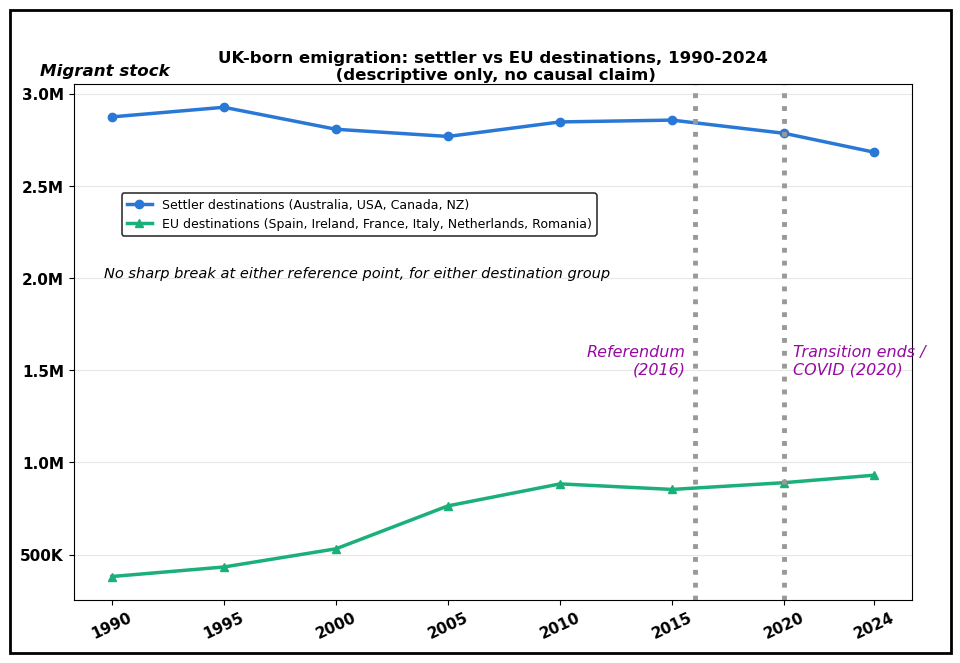

Saved: chart/part2_settler_vs_eu.png


In [19]:
def add_figure_frame(fig, linewidth=2, edgecolor='black', margin=0.005):
    """Draws a rectangular border around the entire figure (outside all subplots)."""
    from matplotlib.patches import Rectangle
    rect = Rectangle(
        (margin, margin), 1 - 2 * margin, 1 - 2 * margin,
        transform=fig.transFigure,
        fill=False,
        edgecolor=edgecolor,
        linewidth=linewidth,
        clip_on=False,
    )
    fig.add_artist(rect)

settler = ['AUS', 'USA', 'CAN', 'NZL']
eu_proper = ['ESP', 'IRL', 'FRA', 'ITA', 'NLD', 'ROU']
settler_total = uk_origin[uk_origin['destination_iso3'].isin(settler)].groupby('year')['migrant_stock'].sum().reindex(YEARS)
eu_total = uk_origin[uk_origin['destination_iso3'].isin(eu_proper)].groupby('year')['migrant_stock'].sum().reindex(YEARS)

fig, ax = plt.subplots(figsize=(9.5, 6.5))
ax.plot(YEARS, settler_total, color=COLORS['settler'], linewidth=2.5, marker='o', markersize=6,
        label='Settler destinations (Australia, USA, Canada, NZ)')
ax.plot(YEARS, eu_total, color=COLORS['eu'], linewidth=2.5, marker='^', markersize=6,
        label='EU destinations (Spain, Ireland, France, Italy, Netherlands, Romania)')
ax.axvline(2016, color='#999999', linestyle=':', linewidth=3.5)
ax.axvline(2020, color='#999999', linestyle=':', linewidth=3.5)

# unified color + size for both reference labels (previously two different purple shades and sizes)
REF_LABEL_COLOR = '#9709A2'
REF_LABEL_FONTSIZE = 11.5
ax.text(2015.6, 1.55e6, 'Referendum\n(2016)', fontsize=REF_LABEL_FONTSIZE, fontstyle='italic',
        color=REF_LABEL_COLOR, va='center', ha='right')
ax.text(2020.4, 1.55e6, 'Transition ends /\nCOVID (2020)', fontsize=REF_LABEL_FONTSIZE, fontstyle='italic',
        color=REF_LABEL_COLOR, va='center', ha='left')

ax.set_xticks(YEARS)
ax.set_xticklabels(YEARS, rotation=25, fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(FuncFormatter(k_m_formatter))

# y-tick styling added -- previously only x-ticks were sized, y-ticks were left at matplotlib default
ax.tick_params(axis='y', labelsize=11)
plt.setp(ax.get_yticklabels(), fontweight='bold')

set_ylabel_top(ax, 'Migrant stock', xpos=-0.04, ypos=1.01, fontsize=12)
ax.grid(axis='y', alpha=0.3)

legend = ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(0.05, 0.80),
                    framealpha=1, frameon=True, edgecolor='#333333')
legend.get_frame().set_linewidth(1.2)

ax.set_title('UK-born emigration: settler vs EU destinations, 1990-2024\n (descriptive only, no causal claim)',
             fontsize=12, fontweight='bold', pad=3)
fig.suptitle('No sharp break at either reference point, for either destination group',
             fontsize=10.5, fontstyle='italic', x=0.37, y=0.60)

plt.tight_layout()

# frame around the whole figure, drawn after tight_layout so it isn't shrunk by it
add_figure_frame(fig, linewidth=2, edgecolor='black')

fig.savefig('chart/part2_settler_vs_eu.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart/part2_settler_vs_eu.png")

**Finding:** neither series shows a break at 2016 or 2020.

- Settler-destination emigration has actually been *declining slowly* since 2015 — a
  trend that predates the referendum, so it cannot be attributed to it.
- EU-destination emigration *grew* through 2015-2020-2024, the opposite direction from
  what a simple "Brexit ended free movement, so EU emigration fell" story would predict.

At this data resolution (5-year snapshots, country-of-birth basis), **no distinguishable
Brexit-adjacent or COVID-adjacent turning point is visible** in UK outward emigration —
for either destination group. This is a legitimate finding in itself: it argues against
reading a dramatic "Brexit changed UK emigration" narrative into this data, and is
consistent with outward emigration being the comparatively minor half of the UK
migration story (see Part 1).

**A natural follow-up: what about everywhere else?** The settler/EU split above only
covers 10 of UK's real top-20 destinations. Adding a third "rest of world" line (all
other verified destinations, i.e. excluding the four artifact-flagged ones -- three
identified earlier, plus Thailand, covered in its own section below) shows what
share of UK emigration these two named groups actually capture, and whether the
remainder moves differently.

In [22]:
grouped_destinations = settler + eu_proper + ARTIFACT_FLAGGED
rest_of_world = uk_origin[~uk_origin['destination_iso3'].isin(grouped_destinations)]
rest_total = rest_of_world.groupby('year')['migrant_stock'].sum().reindex(YEARS)

three_way = pd.DataFrame({'settler': settler_total, 'eu': eu_total, 'rest_of_world': rest_total})
three_way['total'] = three_way.sum(axis=1)
three_way['rest_share_pct'] = (three_way['rest_of_world'] / three_way['total'] * 100).round(1)
three_way

,settler,eu,rest_of_world,total,rest_share_pct
year,,,,,
1990,2875208.0,380564.0,584765.0,3840537.0,15.2
1995,2927430.0,432211.0,557969.0,3917610.0,14.2
2000,2808064.0,530891.0,574058.0,3913013.0,14.7
2005,2769077.0,764000.0,598877.0,4131954.0,14.5
2010,2847912.0,883355.0,642213.0,4373480.0,14.7
2015,2857774.0,853215.0,693888.0,4404877.0,15.8
2020,2786208.0,889891.0,827392.0,4503491.0,18.4
2024,2683941.0,930228.0,936281.0,4550450.0,20.6


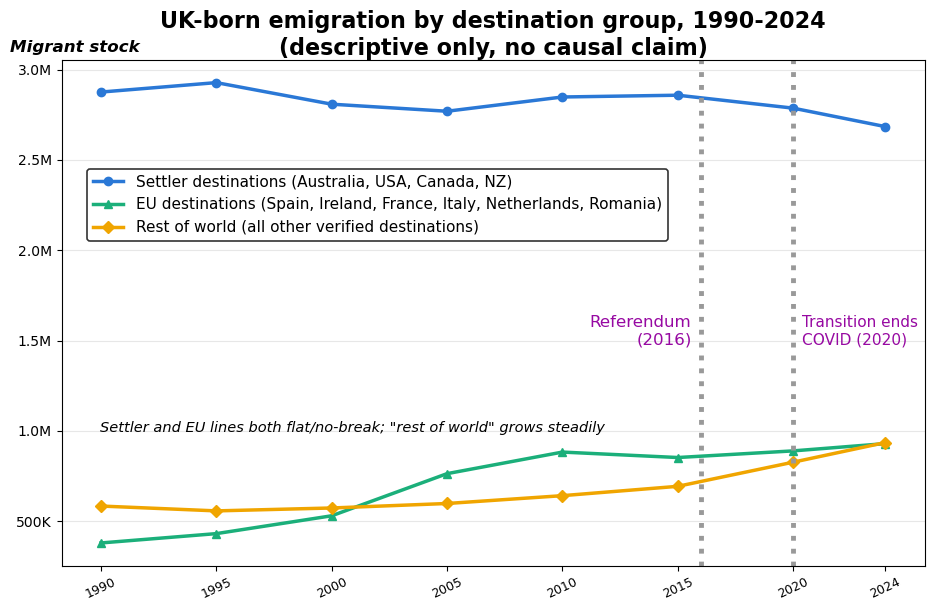

Saved: chart/part2_settler_eu_rest.png


In [23]:
fig, ax = plt.subplots(figsize=(9.5, 6.5))
ax.plot(YEARS, settler_total, color=COLORS['settler'], linewidth=2.5, marker='o', markersize=6,
        label='Settler destinations (Australia, USA, Canada, NZ)')
ax.plot(YEARS, eu_total, color=COLORS['eu'], linewidth=2.5, marker='^', markersize=6,
        label='EU destinations (Spain, Ireland, France, Italy, Netherlands, Romania)')
ax.plot(YEARS, rest_total, color='#f0a500', linewidth=2.5, marker='D', markersize=6,
        label='Rest of world (all other verified destinations)')
ax.axvline(2016, color='#999999', linestyle=':', linewidth=3.5)
ax.axvline(2020, color='#999999', linestyle=':', linewidth=3.5)
ax.text(2015.6, 1.55e6, 'Referendum\n(2016)', fontsize=12, color='#9709A2', va='center', ha='right')
ax.text(2020.4, 1.55e6, 'Transition ends\nCOVID (2020)', fontsize=11, color='#9709A2', va='center', ha='left')
ax.set_xticks(YEARS)
ax.set_xticklabels(YEARS, rotation=25, fontsize=9)
ax.yaxis.set_major_formatter(FuncFormatter(k_m_formatter))
set_ylabel_top(ax, 'Migrant stock', xpos=-0.06, ypos=1.01, fontsize=12)
ax.grid(axis='y', alpha=0.3)
legend = ax.legend(fontsize=11, loc='upper left', bbox_to_anchor=(0.02, 0.80),
                    framealpha=1, frameon=True, edgecolor='#333333')
legend.get_frame().set_linewidth(1.2)
ax.set_title('UK-born emigration by destination group, 1990-2024\n(descriptive only, no causal claim)',
             fontsize=16, fontweight='bold', pad=3)
fig.suptitle('Settler and EU lines both flat/no-break; "rest of world" grows steadily',
             fontsize=10.5,fontstyle ='italic', x=0.37, y=0.30)
plt.tight_layout()
fig.savefig('chart/part2_settler_eu_rest.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart/part2_settler_eu_rest.png")

**Finding:** the rest-of-world share of UK outward emigration (using verified
destinations only -- Thailand excluded, see the dedicated investigation below) grew
steadily across the period -- not concentrated in one destination. Poland leads this
group by a wide margin, with the remainder spread across South Africa, Switzerland,
Turkiye, Sweden and others.

Like the EU line, the rest-of-world line shows **no visible break at 2016 or 2020** --
its growth looks like a steady, multi-decade trend rather than something tied to either
reference point. This reinforces the Part 2c finding: at this data resolution, none of
the three destination groupings show a distinguishable Brexit- or COVID-adjacent shift.

### What the aggregate lines are made of

The settler/EU/rest-of-world aggregates in the chart above can hide offsetting moves
underneath -- a flat total doesn't necessarily mean flat behavior at the country level.
Each group is broken out into its constituent countries below, one chart per group, so
each country's line has room to be read clearly.

In [26]:
def adaptive_formatter(ax):
    ymin, ymax = ax.get_ylim()
    span = ymax - ymin
    if ymax >= 1_000_000 and span < 300_000:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1_000_000:.2f}M'))
    elif ymax >= 1_000 and span < 3_000 and ymax < 1_000_000:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1_000:.1f}K'))
    else:
        ax.yaxis.set_major_formatter(FuncFormatter(k_m_formatter))

def add_figure_frame(fig, linewidth=2, edgecolor='black', margin=0.005):
    """Draws a rectangular border around the entire figure (outside all subplots)."""
    from matplotlib.patches import Rectangle
    rect = Rectangle(
        (margin, margin), 1 - 2 * margin, 1 - 2 * margin,
        transform=fig.transFigure,
        fill=False,
        edgecolor=edgecolor,
        linewidth=linewidth,
        clip_on=False,
    )
    fig.add_artist(rect)

PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#b34aa8', '#f0a500', '#c0392b', '#17a2b8', '#8e44ad']

def small_multiples(codes, ncols, suptitle, filename, figsize):
    nrows = -(-len(codes) // ncols)  # ceil
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    for i, code in enumerate(codes):
        r, c = divmod(i, ncols)
        ax = axes[r][c]
        color = PALETTE[i % len(PALETTE)]
        vals = uk_origin[uk_origin['destination_iso3'] == code].set_index('year')['migrant_stock'].reindex(YEARS)
        ax.plot(YEARS, vals, color=color, linewidth=2.2, marker='o', markersize=4)
        ax.axvline(2016, color='#cccccc', linestyle=':', linewidth=1)
        ax.axvline(2020, color='#cccccc', linestyle=':', linewidth=1)
        adaptive_formatter(ax)
        ax.set_xticks(YEARS); ax.set_xticklabels(YEARS, rotation=40, fontsize=11.5)
        ax.tick_params(axis='y', labelsize=10.5)
        # bold x/y tick labels, matching the rest of the article's charts
        plt.setp(ax.get_xticklabels(), fontweight='bold')
        plt.setp(ax.get_yticklabels(), fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        ax.set_title(country_names[code], fontsize=18.5, fontweight='bold', color='black')
    for j in range(len(codes), nrows * ncols):
        r, c = divmod(j, ncols)
        axes[r][c].axis('off')
    fig.suptitle(suptitle, fontsize=18.5, fontweight='bold', y=0.97)
    fig.text(0.5, -0.04 if nrows == 1 else -0.03,
              'NOTE: each panel has its own y-axis scale -- not directly comparable across panels',
              ha='center', fontsize=14.5, style='italic', color='#2b2b2b')
    plt.tight_layout()
    add_figure_frame(fig, linewidth=2, edgecolor='black')  # frame drawn last so tight_layout doesn't shrink axes to make room
    fig.savefig(f'chart/{filename}', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: chart/{filename}')

country_names.update({'CAN': 'Canada', 'NZL': 'New Zealand', 'ESP': 'Spain', 'IRL': 'Ireland',
                       'FRA': 'France', 'NLD': 'Netherlands'})
rest_top5 = ['POL', 'ZAF', 'CHE', 'TUR', 'SWE']  # THA excluded (data artifact -- see investigation below); SWE replaces it

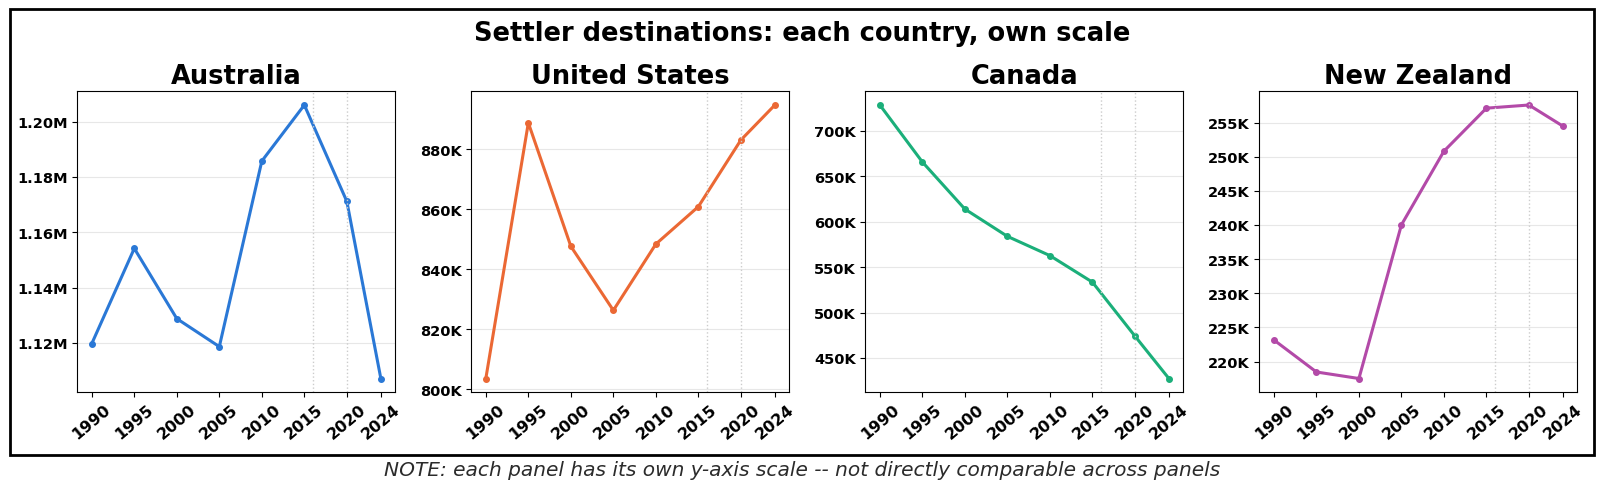

Saved: chart/part2_settler_smallmult.png


In [27]:
small_multiples(settler, 4,
                 'Settler destinations: each country, own scale',
                 'part2_settler_smallmult.png', figsize=(16, 4.5))

**Finding:** the near-flat settler aggregate is actually **Canada in steady decline**
(728K -> 427K, -41% over 34 years) offsetting Australia's post-2015 dip and USA/NZ's
relative stability -- not four countries moving together. Canada's decline is smooth and
long-running, showing no kink at either 2016 or 2020.

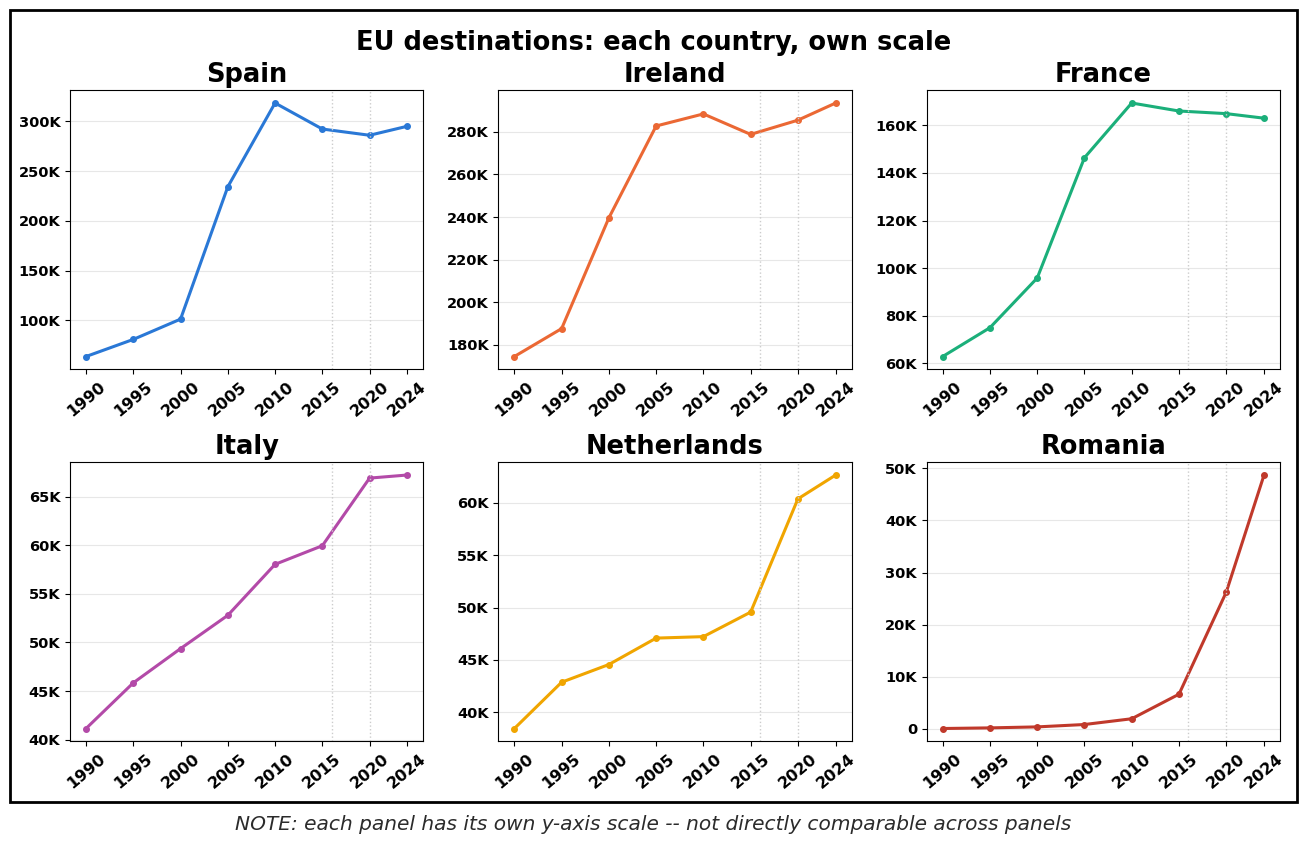

Saved: chart/part2_eu_smallmult.png


In [29]:
small_multiples(eu_proper, 3,
                 'EU destinations: each country, own scale',
                 'part2_eu_smallmult.png', figsize=(13, 8))

**Finding:** dominated by **Spain's sharp 2000-2010 surge** (63K -> 318K, a 5x increase
in a decade -- plausibly retiree/lifestyle migration) and Ireland's earlier, steadier
rise. Italy and the Netherlands barely move across the whole 34 years. Romania only
starts growing after 2015 from a near-zero base -- worth noting this is UK-born people
moving *to* Romania, a much smaller and structurally different flow than the well-known
Romania-to-UK labor migration story covered elsewhere in this notebook.

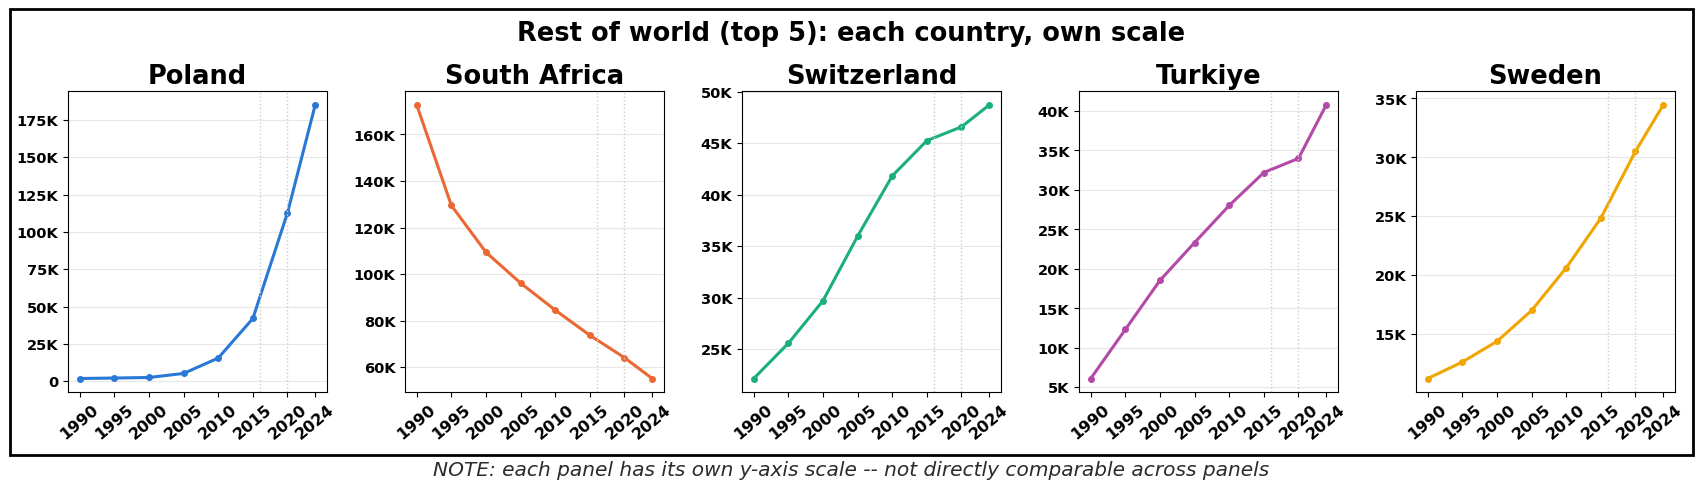

Saved: chart/part2_rest_smallmult.png


In [31]:
small_multiples(rest_top5, 5,
                 'Rest of world (top 5): each country, own scale',
                 'part2_rest_smallmult.png', figsize=(17, 4.5))

**Finding:** the most striking of the five panels. **Poland rockets from near-zero to
185K** (overtaking every other verified country in this group by 2024), while **South
Africa is in steady decline** (173K -> 55K) -- the two lines cross around 2015. Poland's
number is unusual enough to warrant its own investigation, below -- as, separately, is
Thailand's, which is excluded from this chart entirely for reasons explained next.

### Investigating the Poland spike

A 103x increase in UK-born people living in Poland (1,793 in 1990 -> 184,964 in 2024) is
large enough to need scrutiny before featuring it, rather than taking it at face value.

**Most plausible mechanism:** this is very likely linked to the large Polish
labor-migration wave into the UK following Poland's 2004 EU accession. UK migration
statistics explicitly track UK-born children of Polish migrants as a distinct group from
Poland-born migrants themselves -- official data separately identifies roughly 360,000
UK-born children who were not British citizens living in England and Wales as of the
2021 Census. If a share of Polish migrant families later returned to Poland (a
well-documented phenomenon), their UK-born children would appear in this dataset as
"UK-born people living in Poland" -- exactly the pattern seen here, with growth
beginning modestly in the 2000-2010 window (as the first children were born) and
accelerating from 2010 onward (as families reached return-migration age).

**A more significant finding, found while checking this:** external research on Polish
migrants in the UK states that since the 2016 referendum, the Office for National
Statistics documented roughly a quarter decline in the UK's Polish population, with a
further drop following COVID-19 -- the estimated Polish citizen population fell from
about 818,000 in 2019 to roughly 691,000 by the end of 2020, a ~16% single-year decline.
**This dataset's own Poland-into-UK figures show the opposite direction over the same
window** (826,408 in 2015 -> 902,193 in 2024, with continuous growth through 2020).

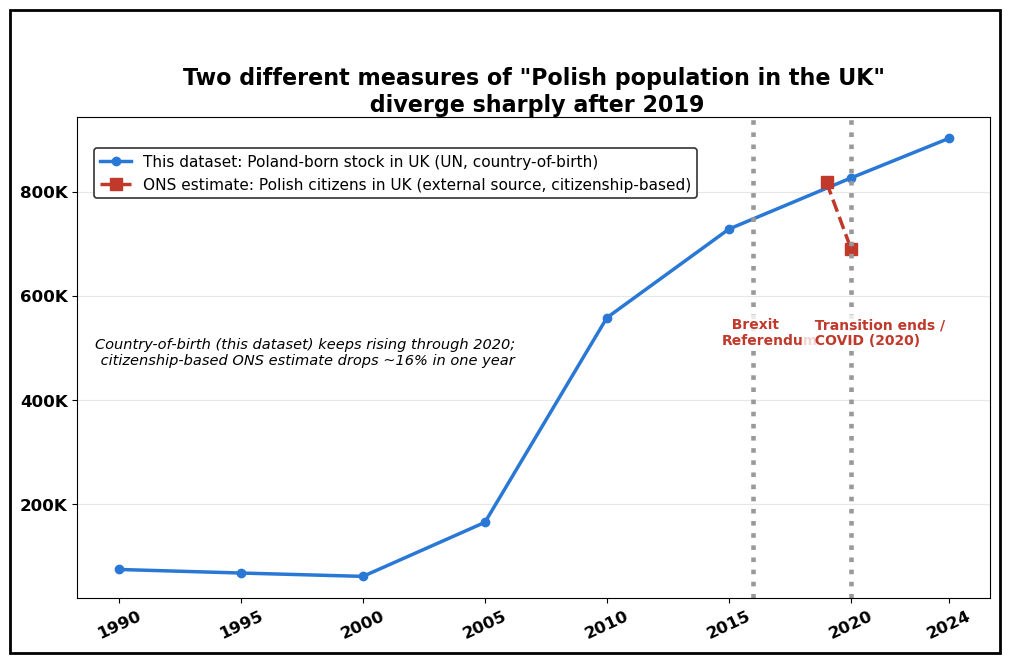

Saved: chart/part2_poland_ons_comparison.png


In [34]:
def add_figure_frame(fig, linewidth=2, edgecolor='black', margin=0.005):
    """Draws a rectangular border around the entire figure (outside all subplots)."""
    from matplotlib.patches import Rectangle
    rect = Rectangle(
        (margin, margin), 1 - 2 * margin, 1 - 2 * margin,
        transform=fig.transFigure,
        fill=False,
        edgecolor=edgecolor,
        linewidth=linewidth,
        clip_on=False,
    )
    fig.add_artist(rect)

pol_in = uk_dest[uk_dest['origin_iso3'] == 'POL'].set_index('year')['migrant_stock'].reindex(YEARS)
# External reference points (ONS, citizenship-based) -- NOT from gravity_df, cited separately for comparison only
ons_years = [2019, 2020]
ons_polish_citizens = [818000, 691000]

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.plot(YEARS, pol_in, color='#2a78d6', linewidth=2.5, marker='o', markersize=6,
        label='This dataset: Poland-born stock in UK (UN, country-of-birth)')
ax.plot(ons_years, ons_polish_citizens, color='#c0392b', linewidth=2.5, marker='s', markersize=8, linestyle='--',
        label='ONS estimate: Polish citizens in UK (external source, citizenship-based)')

ax.axvline(2016, color='#999999', linestyle=':', linewidth=3.3)
ax.axvline(2020, color='#999999', linestyle=':', linewidth=3.3)

# reference-line labels, unified color/style to match the rest of the article (grey line + red bold text + white bbox)
REF_LABEL_COLOR = '#c0392b'
REF_LABEL_BBOX = dict(facecolor='white', edgecolor='none', alpha=0.8, pad=2)
ax.text(2014.7, 500000, '  Brexit\nReferendum', fontsize=10, color=REF_LABEL_COLOR, fontweight='bold',
        rotation=0, va='bottom', bbox=REF_LABEL_BBOX)
# second reference line was previously unlabeled -- added for consistency with the other charts' paired annotations
ax.text(2018.1, 500000, '  Transition ends /\n  COVID (2020)', fontsize=10, color=REF_LABEL_COLOR, fontweight='bold',
        rotation=0, va='bottom', bbox=REF_LABEL_BBOX)

ax.yaxis.set_major_formatter(FuncFormatter(k_m_formatter))
ax.set_xticks(YEARS); ax.set_xticklabels(YEARS, rotation=25, fontsize=12, fontweight='bold')

# y-tick styling added -- previously only x-ticks were sized, y-ticks were left at matplotlib default
ax.tick_params(axis='y', labelsize=12)
plt.setp(ax.get_yticklabels(), fontweight='bold')

ax.grid(axis='y', alpha=0.3)
legend = ax.legend(fontsize=11, loc='upper left', bbox_to_anchor=(0.01, 0.95),
                    framealpha=1, frameon=True, edgecolor='#333333')
legend.get_frame().set_linewidth(1.2)

ax.set_title('Two different measures of "Polish population in the UK"\n diverge sharply after 2019',
             fontsize=16, fontweight='bold', pad=4)
fig.suptitle('Country-of-birth (this dataset) keeps rising through 2020;\n citizenship-based ONS estimate drops ~16% in one year',
             fontsize=10.5, fontstyle='italic', x=0.3, y=0.49)

plt.tight_layout()

# frame around the whole figure, drawn after tight_layout so it isn't shrunk by it
add_figure_frame(fig, linewidth=2, edgecolor='black')

fig.savefig('chart/part2_poland_ons_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart/part2_poland_ons_comparison.png")

**Most plausible reconciliation:** these two measures are counting different things, not
disagreeing about the same fact. Sixteen years after 2004 accession is long enough for
large numbers of Poland-born UK residents to have naturalized as British citizens --
which removes them from a *citizenship*-based count (ONS) while leaving them in a
*country-of-birth*-based count (this dataset, and the UN source it comes from). Real
return migration and rising naturalization can both be happening at once, pulling the
two measures in different directions.

**Why this matters for the piece:** this is the clearest concrete illustration available
of the "country-of-birth, not citizenship" limitation stated in Section 2's framing --
not just an abstract caveat, but a specific case where it visibly changes the picture.
It also means the earlier "no break in EU-accession-country growth" finding should be
read as **specific to the country-of-birth measure this dataset uses** -- a
citizenship-based measure, which this dataset cannot construct, shows a real and
externally-documented decline beginning right around the referendum. Both findings are
accurate for what they measure; neither is the complete picture on its own.

### Investigating the Thailand jump

Thailand showed an 8.5x increase in UK-born stock in a single window (2000-2005: 5,180
-> 44,226) -- large and sudden enough to check before it was used in the "rest of world"
totals above. Unlike Poland's smooth, explainable growth curve, this is a sharp,
single-window discontinuity, which is a different and more concerning shape.

In [37]:
tha_dest = gravity_df[gravity_df['destination_iso3'] == 'THA']
tha_pivot = tha_dest.pivot_table(index='origin_iso3', columns='year', values='migrant_stock')
tha_2000_2005 = tha_pivot[[2000, 2005]].copy()
tha_2000_2005['ratio'] = tha_2000_2005[2005] / tha_2000_2005[2000]
tha_2000_2005.sort_values('ratio', ascending=False)

year,2000,2005,ratio
origin_iso3,,,
GBR,5180.0,44226.0,8.537838
FRA,1845.0,11837.0,6.415718
KHM,24956.0,149042.0,5.972191
PHL,1652.0,9362.0,5.667070
MMR,136674.0,696293.0,5.094553
DEU,3050.0,13375.0,4.385246
USA,5263.0,22201.0,4.218317
JPN,11657.0,45200.0,3.877498
LAO,33729.0,125074.0,3.708204


**Finding: this is a broad, Thailand-side data discontinuity, not a UK-specific
pattern.** Nearly every origin country into Thailand jumps sharply in the exact same
2000-2005 window -- Myanmar (5.1x), Cambodia (6.0x), Laos (3.7x), Japan (3.9x), the UK
(8.5x), Germany (4.4x), France (6.4x), and the Philippines (5.7x) all show multi-fold
increases concentrated in this single snapshot transition. **China's figure is exactly
identical between 2000 and 2005** (141,649 both years) -- the same carried-forward, not
re-measured signature already seen with Malaysia in the South Asia analysis referenced
in the Piece 1 handoff.

This is most plausibly a change in Thailand's own foreign-resident data collection or
census methodology around 2005, not a real migration surge for any of the eight-plus
origin countries showing the same-window jump simultaneously. It is a different
statistical signature than the uniform-scaling test used elsewhere in this notebook (a
broad, magnitude-varying level jump across many origins in one window, rather than a
near-identical ratio across origins) -- which is why it passed the original test and
needed a separate check, prompted by the size of Thailand's number rather than a
scheduled test.

**Thailand is added to `ARTIFACT_FLAGGED` and excluded from all outward totals in this
notebook, including the top-20 destination chart, the settler/EU/rest-of-world
aggregate, and the rest-of-world small-multiples chart** (where Sweden -- checked and
clean on both tests -- takes its place as the fifth country).

### Checking the Middle East

Every regional grouping so far (settler, EU, rest-of-world) has been checked in
detail, but the Middle East hasn't been looked at specifically. Worth doing given
Piece 1's own finding that Gulf states (UAE, Kuwait, Oman, Qatar, Bahrain) were
excluded for South Asian migration corridors due to a uniform-scaling artifact --
that exclusion was carried over here by assumption for the outward destination
list, but never actually re-verified for the UK corridor specifically. Checking it
properly now.

In [40]:
middle_east = ['ARE', 'SAU', 'QAT', 'KWT', 'OMN', 'BHR', 'ISR', 'JOR', 'LBN', 'IRQ', 'IRN', 'YEM', 'SYR']

# coverage check -- which of these have any UK-origin data at all
coverage = {code: len(uk_origin[uk_origin['destination_iso3'] == code]) for code in middle_east}
print("Rows of UK-origin data, by Middle East destination:")
for code, n in coverage.items():
    print(f'  {code}: {n} rows')

# artifact check on the 5 that have data
me_with_data = [code for code, n in coverage.items() if n > 0]
print(f'\nRunning uniform-scaling check on the {len(me_with_data)} destinations with data: {me_with_data}')
for code in me_with_data:
    flags = scaling_artifact_check(code, gravity_df, year_pairs)
    status = f'FLAGGED: {flags}' if flags else 'clean'
    print(f'  {code}: {status}')

Rows of UK-origin data, by Middle East destination:
  ARE: 8 rows
  SAU: 0 rows
  QAT: 8 rows
  KWT: 8 rows
  OMN: 0 rows
  BHR: 8 rows
  ISR: 8 rows
  JOR: 0 rows
  LBN: 0 rows
  IRQ: 0 rows
  IRN: 0 rows
  YEM: 0 rows
  SYR: 0 rows

Running uniform-scaling check on the 5 destinations with data: ['ARE', 'QAT', 'KWT', 'BHR', 'ISR']
  ARE: FLAGGED: [(2010, 2015, 0.00022, 33), (2015, 2020, 0.00025, 33), (2020, 2024, 0.0001, 33)]
  QAT: FLAGGED: [(2020, 2024, 0.00019, 33)]
  KWT: FLAGGED: [(2015, 2020, 0.0006, 33), (2020, 2024, 0.00012, 33)]
  BHR: FLAGGED: [(2010, 2015, 0.0011, 33), (2015, 2020, 0.00074, 33), (2020, 2024, 0.00043, 33)]
  ISR: clean


**Finding:** only 5 of 13 Middle East countries checked have any UK-origin data at
all -- Saudi Arabia, Oman, Jordan, Lebanon, Iraq, Iran, Yemen, and Syria are entirely
absent from this dataset for the UK-as-origin direction, not excluded for quality
reasons, simply outside what the UN source reports for these specific pairs. Worth
noting: Saudi Arabia's absence here is a genuine, separate coverage gap -- it doesn't
contradict Piece 1's finding that Saudi Arabia is the largest single destination for
South Asian migrants globally, since that finding was about a different origin
direction entirely.

Of the five with data, **UAE, Kuwait, Qatar, and Bahrain all show the uniform-scaling
artifact** in recent snapshot windows -- confirming, with actual verification rather
than assumption, that Piece 1's Gulf-states exclusion does carry over to the UK
corridor specifically. These four are added to `ARTIFACT_FLAGGED`.

**A calibration check makes clear this is a severe undercount, not just an unreliable
trend.** This dataset's 2024 figure for UK-born residents in the UAE is 27,318.
Independently reported figures on the UK's actual resident population in the UAE put
it at roughly 240,000 as of 2026 -- nearly a 9x gap. This is a large, real, and
well-established population (drawn by tax-free income, finance and energy-sector
employment, and lifestyle), not a small or uncertain one. The most likely explanation
is that the UAE does not conduct the kind of detailed country-of-birth reporting to
the UN that produces reliable bilateral figures elsewhere in this dataset -- so the
uniform-scaling signature found earlier isn't just a growth-pattern quirk, it's a
symptom of the underlying number itself being badly understated. **Excluding UAE from
this dataset's totals is a statement about this dataset's reliability for this
destination, not a claim that UK-UAE migration is small or absent** -- the opposite
is true in reality.

One further, separate note for completeness: a large, largely temporary displacement
of British residents from the UAE did occur amid a regional war beginning in
February 2026 (Iran struck the UAE directly; reporting suggests roughly one in eight
of the UAE's British residents left at the peak of the conflict). This happened after
this dataset's final snapshot (2024) and is therefore invisible to it regardless of
any data-quality question -- included here only for completeness, not as evidence for
or against the artifact finding above.

**Israel is clean across every single window** -- the one genuinely verified Middle
East destination in this dataset, and its scale (tens of thousands, not hundreds of
thousands) makes a similar severe-undercount check less critical, though it hasn't
been independently cross-checked against an external source the way UAE was here.
Its growth is smooth and steadily decelerating (13,224 in 1990 -> 26,577 in 2024,
roughly doubling over 34 years, with no break at 2016 or 2020), consistent with the
pattern seen everywhere else in this notebook.

In [42]:
# Recorded for completeness -- UAE/Kuwait/Qatar/Bahrain were never part of the top-20
# outward or top-5 rest-of-world totals used elsewhere in this notebook, so this doesn't
# change any figure already reported. It's the confirmation that Piece 1's Gulf-states
# exclusion holds for this corridor too, not a correction to anything computed so far.

isr = uk_origin[uk_origin['destination_iso3'] == 'ISR'].set_index('year')['migrant_stock'].reindex(YEARS)
isr

year
1990    13224.0
1995    16327.0
2000    18222.0
2005    19837.0
2010    21530.0
2015    23213.0
2020    25021.0
2024    26577.0
Name: migrant_stock, dtype: float64

---
## Part 3: Breaking down the inward side — who is arriving, and why

Part 1 established that inward migration is the dominant driver of UK demographic
change. This section breaks that inward flow down by origin country, using three
categories:

1. **Former UK colonial tie** (`colony`=1 in the CEPII data — the single strongest
   predictor identified across the whole project)
2. **Europe, no colonial tie** (`colony`=0, `Region_origin`='Europe')
3. **Rest of world** (`colony`=0, non-Europe)

**A real categorization conflict, resolved explicitly:** some countries are both a
former colony *and* geographically European — Ireland is the clearest case in the top
30. Colonial tie is given priority here, since it's the strongest predictor this whole
project has found; Ireland and the USA (also `colony`=1) are categorized as colonial-tie
countries, not by continent. This is a judgment call, not a neutral default — flagged
explicitly since it shapes how the chart reads.

**Data-quality check (same discipline as the outward destinations):** tested whether
UK's own inbound data shows the uniform-scaling artifact signature across its origin
countries, in every snapshot window. It does not (std well above the 0.01 threshold in
every window) — UK's inbound bilateral data is clean at the aggregate level.

In [44]:
top30_inward = (uk_dest[uk_dest['year'] == 2024]
                .sort_values('migrant_stock', ascending=False)
                .head(30).copy())

def categorize_origin(row):
    if row['colony'] == 1:
        return 'colony'
    elif row['Region_origin'] == 'Europe':
        return 'europe'
    else:
        return 'rest'

top30_inward['category'] = top30_inward.apply(categorize_origin, axis=1)

CAT_COLORS = {'colony': '#c0392b', 'europe': '#2a78d6', 'rest': '#f0a500'}
CAT_LABELS = {'colony': 'Former UK colonial tie', 'europe': 'Europe (no colonial tie)', 'rest': 'Rest of world'}

top30_inward['category'].value_counts()

category
colony    15
europe     9
rest       6
Name: count, dtype: int64

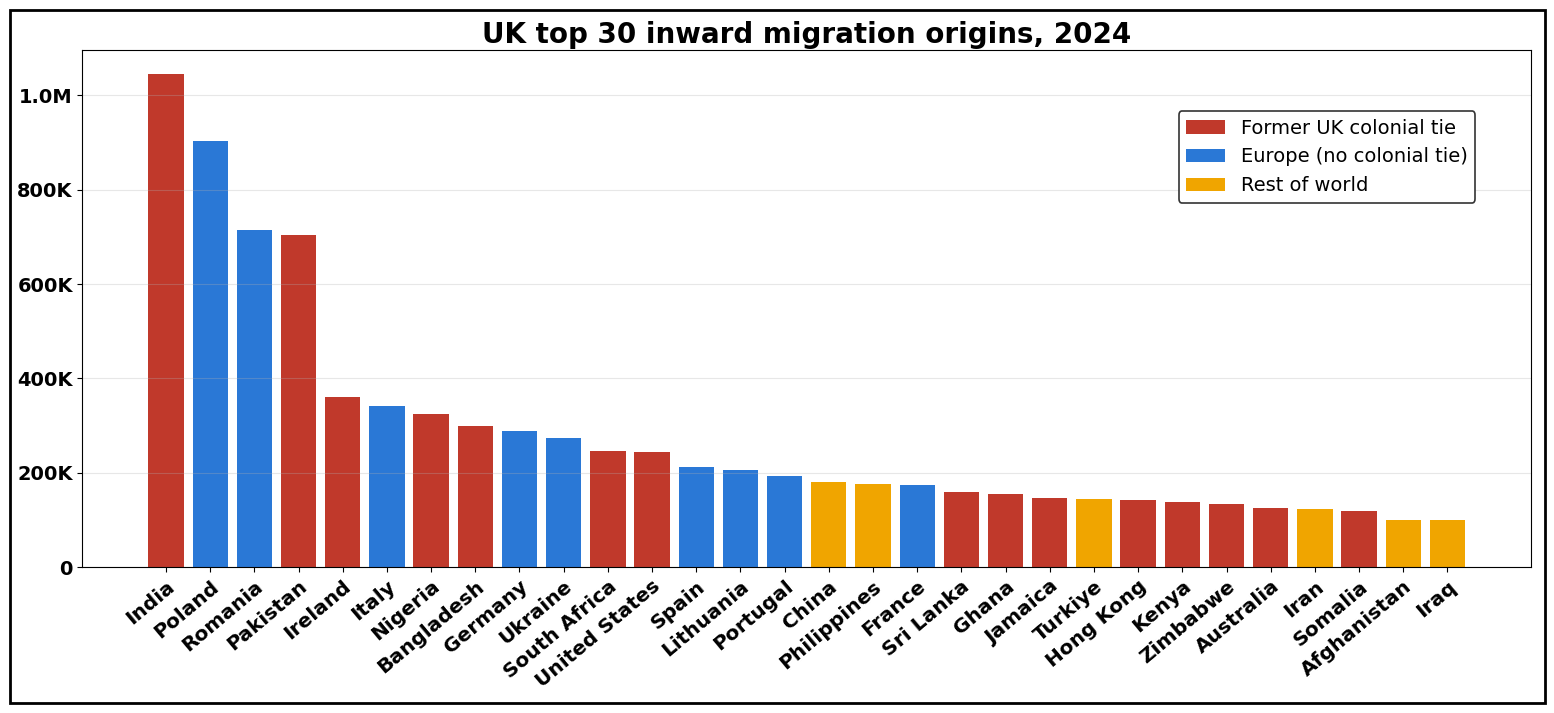

Saved: chart/part3_inward_by_category.png


In [45]:
def add_figure_frame(fig, linewidth=2, edgecolor='black', margin=0.005):
    """Draws a rectangular border around the entire figure (outside all subplots)."""
    from matplotlib.patches import Rectangle
    rect = Rectangle(
        (margin, margin), 1 - 2 * margin, 1 - 2 * margin,
        transform=fig.transFigure,
        fill=False,
        edgecolor=edgecolor,
        linewidth=linewidth,
        clip_on=False,
    )
    fig.add_artist(rect)

colors = top30_inward['category'].map(CAT_COLORS)

# ---- display-only label overrides (doesn't touch the underlying data) ----
LABEL_OVERRIDES = {
    'Hong Kong SAR, China': 'Hong Kong',
    'Iran, Islamic Rep.': 'Iran',
}
xtick_labels = top30_inward['Country_origin_x'].replace(LABEL_OVERRIDES)

# ---- knobs you can tune ----
XTICK_LABELSIZE = 14.5
YTICK_LABELSIZE = 14
LEGEND_LOC = 'upper left'
LEGEND_BBOX = (0.75, 0.90)   # pushes legend just outside the right edge of the axes
LEGEND_FRAME_EDGECOLOR = '#333333'
LEGEND_FRAME_LINEWIDTH = 1.2

fig, ax = plt.subplots(figsize=(15.5, 7))
ax.bar(xtick_labels, top30_inward['migrant_stock'], color=colors)
ax.yaxis.set_major_formatter(FuncFormatter(k_m_formatter))
plt.setp(ax.get_xticklabels(), rotation=40, ha='right', rotation_mode='anchor')

# manual x/y tick label sizes (kept separate from the plt.setp rotation call above)
ax.tick_params(axis='x', labelsize=XTICK_LABELSIZE)
ax.tick_params(axis='y', labelsize=YTICK_LABELSIZE)
plt.setp(ax.get_xticklabels(), fontweight='bold')
plt.setp(ax.get_yticklabels(), fontweight='bold')

ax.grid(axis='y', alpha=0.3)

legend_elems = [Patch(facecolor=c, label=CAT_LABELS[k]) for k, c in CAT_COLORS.items()]
legend = ax.legend(
    handles=legend_elems,
    fontsize=14,
    loc=LEGEND_LOC,
    bbox_to_anchor=LEGEND_BBOX,
    framealpha=1,
    frameon=True,
    edgecolor=LEGEND_FRAME_EDGECOLOR,
)
legend.get_frame().set_linewidth(LEGEND_FRAME_LINEWIDTH)

ax.set_title('UK top 30 inward migration origins, 2024', fontsize=20, fontweight='bold', pad=4)
plt.tight_layout()

# frame around the whole figure, drawn after tight_layout so it isn't shrunk by it
add_figure_frame(fig, linewidth=2, edgecolor='black')

fig.savefig('chart/part3_inward_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart/part3_inward_by_category.png")

**Reading the combined chart:** colonial-tie and European-origin countries interleave
across the top of the ranking — "rest of world" only appears from around rank 19
downward. This single-axis view is the most direct comparison across categories, but it
compresses smaller countries. The panel below trades that direct comparability for a
clearer look at the shape *within* each category — note the independent y-axis per
panel, which is stated explicitly since it changes what a bar's height means from panel
to panel.

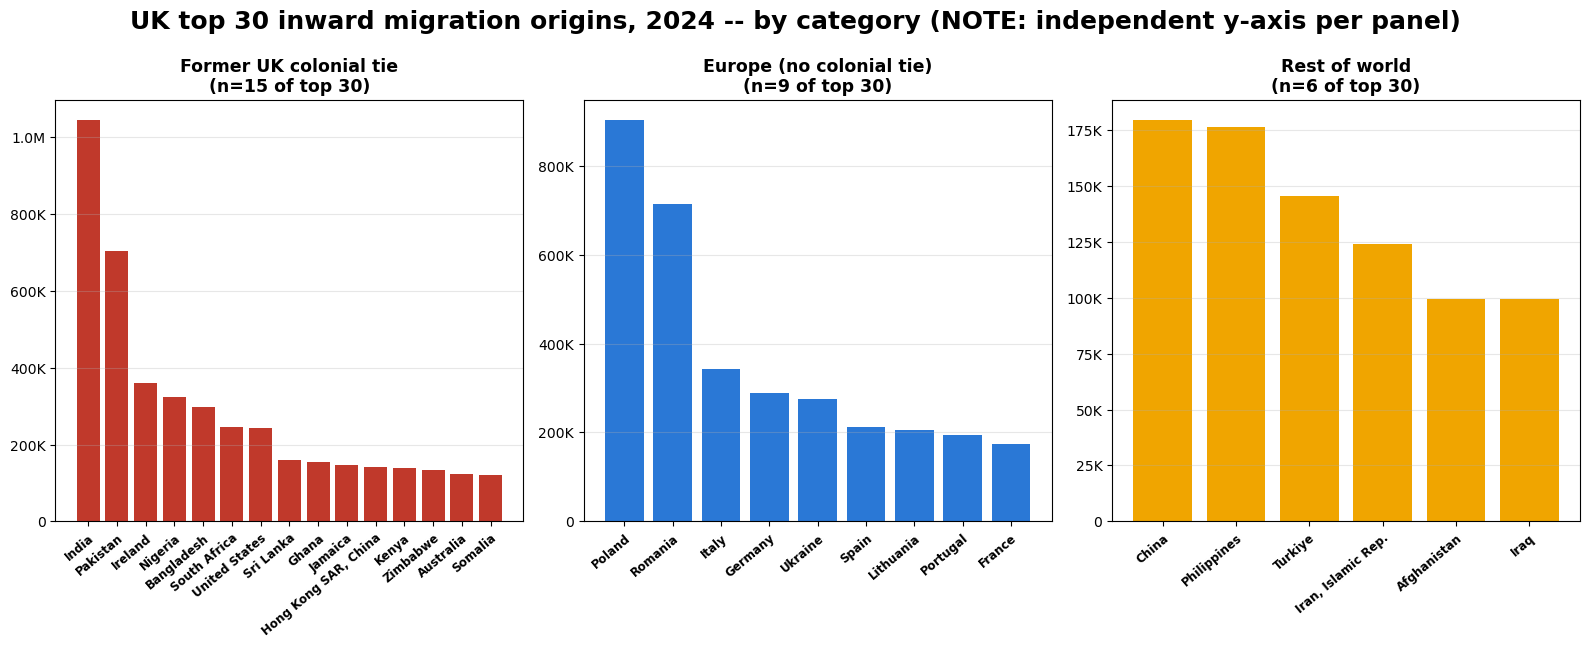

Saved: chart/part3_inward_subplots.png


In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6.5))
for ax, cat in zip(axes, ['colony', 'europe', 'rest']):
    sub = top30_inward[top30_inward['category'] == cat].sort_values('migrant_stock', ascending=False)
    ax.bar(sub['Country_origin_x'], sub['migrant_stock'], color=CAT_COLORS[cat])
    ax.yaxis.set_major_formatter(FuncFormatter(k_m_formatter))
    plt.setp(ax.get_xticklabels(), rotation=40, ha='right', rotation_mode='anchor',fontweight='bold', fontsize=8.5)
    ax.grid(axis='y', alpha=0.3)
    ax.set_title(f'{CAT_LABELS[cat]}\n(n={len(sub)} of top 30)', fontsize=12.5, fontweight='bold')

fig.suptitle('UK top 30 inward migration origins, 2024 -- by category (NOTE: independent y-axis per panel)',
             fontsize=18, fontweight='bold', y=0.99)
plt.tight_layout()
fig.savefig('chart/part3_inward_subplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart/part3_inward_subplots.png")

**Finding:** of the top 30 inward origins, 15 carry a former colonial tie, 9 are
European with no colonial tie, and 6 fall into "rest of world." Two things stand out in
the subplot view specifically:

- **The colonial-tie group has the steepest internal drop-off** — India and Pakistan
  alone (1.04M + 0.70M) roughly equal the combined total of the next 13 colonial-tie
  countries in the top 30.
- **"Rest of world" is comparatively flat** — China, Philippines, Turkiye, Iran,
  Afghanistan, and Iraq sit within a relatively narrow band (99K-179K), unlike the steep
  drop-offs in the other two groups.

**Caveat carried over from Part 1's framing constraint:** none of this should be read as
evidence about *why* people migrate to the UK from any given country, only about the
current scale and category mix of who has. As with the rest of this notebook, this is
descriptive, not causal.

### A coverage limitation worth stating plainly

The UK has only **35 total reported origin countries** in this dataset as a destination
-- not the ~230 in the full panel. This is a genuine property of the underlying UN
Migrant Stock data (destination countries vary widely in how many bilateral origins they
report -- Germany reports even fewer at 27, Australia far more at 197) rather than a
pipeline issue. It means the "top 30 inward" chart above is close to the **entire**
UN-reported picture for the UK, not a curated slice of a much larger set. Worth stating
explicitly so the piece doesn't imply more completeness than the data actually has.

One direct consequence: of the ten 2004/2007 EU-accession countries (the "A8" -- Poland,
Czechia, Hungary, Slovakia, Slovenia, Estonia, Latvia, Lithuania -- plus "A2" -- Romania,
Bulgaria), only **three** (Poland, Romania, Lithuania) have any reported rows with the UK
as destination. The other seven are absent from this destination's reporting entirely,
not because their populations are literally zero, but because they fall outside what the
UN dataset captures for this specific destination country.

### The hardest test available: EU-accession-country migration

Poland, Romania, and Lithuania are the most direct test case available for a Brexit
effect: their UK residency was built specifically on EU free movement, activated by
accession (Poland/Lithuania 2004, Romania 2007) and ended by Brexit's transition period
closing in 2020. If a Brexit-specific break exists anywhere in this dataset, this
population is where it should be most visible.

In [51]:
accession_countries = ['POL', 'ROU', 'LTU']  # the only 3 of 10 A8/A2 countries reported for GBR as destination
accession_sub = uk_dest[uk_dest['origin_iso3'].isin(accession_countries)]
accession_total = accession_sub.groupby('year')['migrant_stock'].sum().reindex(YEARS)

periods = list(zip(YEARS[:-1], YEARS[1:]))
annualized_growth = []
for y1, y2 in periods:
    n_years = y2 - y1
    multiple = accession_total[y2] / accession_total[y1]
    annualized_growth.append((multiple ** (1/n_years) - 1) * 100)

growth_table = pd.DataFrame({
    'period': [f'{y1}-{y2}' for y1, y2 in periods],
    'total_multiple': [round(accession_total[y2]/accession_total[y1], 2) for y1, y2 in periods],
    'annualized_pct': [round(g, 1) for g in annualized_growth]
})
growth_table

,period,total_multiple,annualized_pct
0,1990-1995,0.93,-1.4
1,1995-2000,0.94,-1.1
2,2000-2005,2.80,22.9
3,2005-2010,3.65,29.6
4,2010-2015,1.49,8.3
5,2015-2020,1.43,7.4
6,2020-2024,1.21,4.9


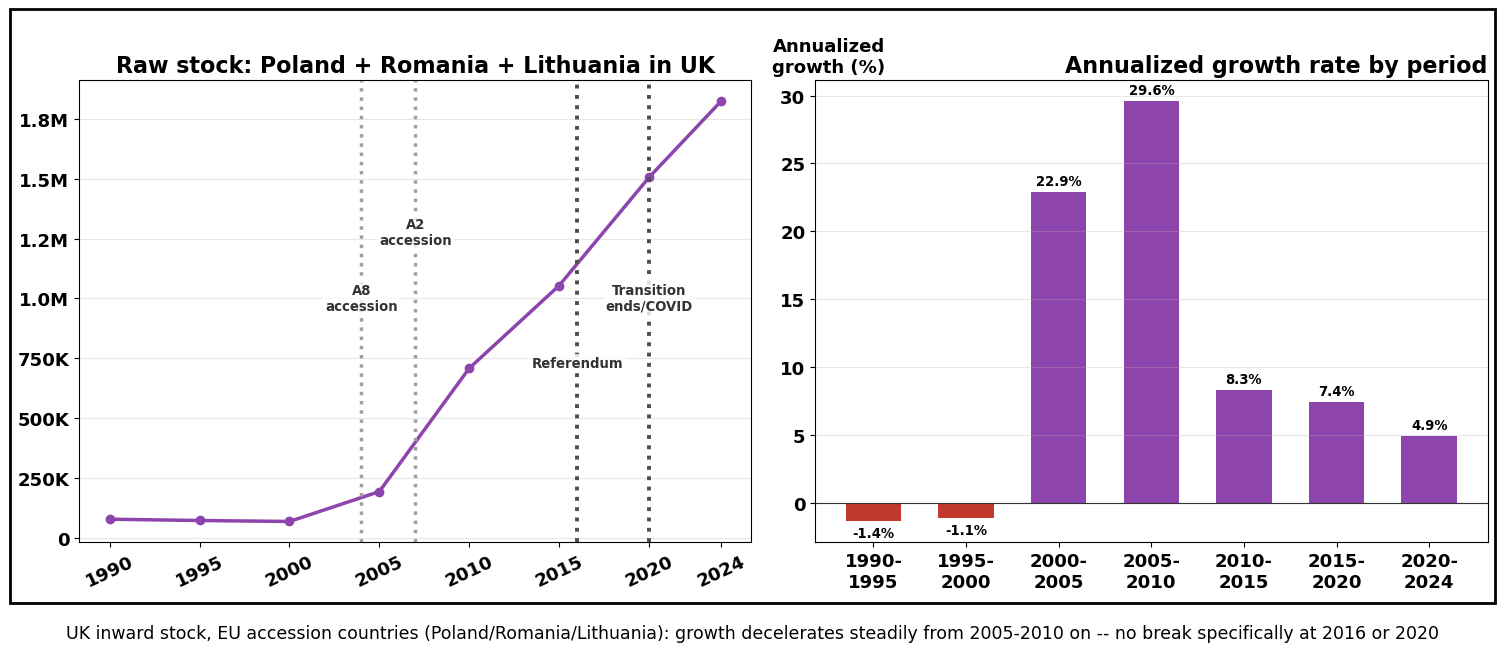

Saved: chart/part3_accession_countries.png


In [52]:
def add_figure_frame(fig, linewidth=2, edgecolor='black', margin=0.005):
    """Draws a rectangular border around the entire figure (outside all subplots)."""
    from matplotlib.patches import Rectangle
    rect = Rectangle(
        (margin, margin), 1 - 2 * margin, 1 - 2 * margin,
        transform=fig.transFigure,
        fill=False,
        edgecolor=edgecolor,
        linewidth=linewidth,
        clip_on=False,
    )
    fig.add_artist(rect)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ---- reference-line colors: accession vs. Brexit markers now visually distinct ----
ACCESSION_LINE_COLOR = '#a0a0a0'   # A8 / A2 accession -- lighter, "background" context
BREXIT_LINE_COLOR = '#4d4d4d'      # Referendum / Transition -- darker, the focal reference points
LABEL_BBOX = dict(facecolor='white', edgecolor='none', alpha=0.8, pad=2)  # legible over any line/gridline

ax1.plot(YEARS, accession_total, color='#8e44ad', linewidth=2.5, marker='o', markersize=6)
ax1.axvline(2004, color=ACCESSION_LINE_COLOR, linestyle=':', linewidth=2.5)
ax1.axvline(2007, color=ACCESSION_LINE_COLOR, linestyle=':', linewidth=2.5)
ax1.axvline(2016, color=BREXIT_LINE_COLOR, linestyle=':', linewidth=2.8)
ax1.axvline(2020, color=BREXIT_LINE_COLOR, linestyle=':', linewidth=2.8)

# labels: raised off the bottom (clear of the rotated x-tick labels), horizontal for readability,
# white bbox so they stay legible regardless of what's behind them
top = accession_total.max()
LABEL_TEXT_COLOR = '#333333'   # unified color across all four annotations for a consistent visual weight
ax1.text(2004, top * 0.55, 'A8\naccession', fontsize=9.5, color=LABEL_TEXT_COLOR, fontweight='bold',
          ha='center', va='center', bbox=LABEL_BBOX)
ax1.text(2007, top * 0.70, 'A2\naccession', fontsize=9.5, color=LABEL_TEXT_COLOR, fontweight='bold',
          ha='center', va='center', bbox=LABEL_BBOX)
ax1.text(2016, top * 0.40, 'Referendum', fontsize=9.5, color=LABEL_TEXT_COLOR, fontweight='bold',
          ha='center', va='center', bbox=LABEL_BBOX)
ax1.text(2020, top * 0.55, 'Transition\nends/COVID', fontsize=9.5, color=LABEL_TEXT_COLOR, fontweight='bold',
          ha='center', va='center', bbox=LABEL_BBOX)

ax1.yaxis.set_major_formatter(FuncFormatter(k_m_formatter))
ax1.set_xticks(YEARS); ax1.set_xticklabels(YEARS, rotation=25, fontsize=13, fontweight='bold')
ax1.tick_params(axis='y', labelsize=13)
plt.setp(ax1.get_yticklabels(), fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_title('Raw stock: Poland + Romania + Lithuania in UK', fontsize=16, fontweight='bold')

# ---- knobs you can tune ----
POS_COLOR = '#8e44ad'
NEG_COLOR = '#c0392b'
LABEL_COLOR = 'black'
YLABEL_FONTSIZE = 13
POS_LABEL_OFFSET = max(annualized_growth) * 0.01
NEG_LABEL_OFFSET = abs(min(annualized_growth)) * 0.25

bar_colors = [POS_COLOR if v >= 0 else NEG_COLOR for v in annualized_growth]
ax2.bar(range(len(periods)), annualized_growth, color=bar_colors, width=0.6)
ax2.set_ylabel('Annualized\ngrowth (%)', fontweight='bold', rotation=0, fontsize=YLABEL_FONTSIZE)
ax2.yaxis.set_label_coords(0.02, 1.01)

ax2.set_xticks(range(len(periods)))
ax2.set_xticklabels([f'{y1}-\n{y2}' for y1, y2 in periods], fontsize=13, fontweight='bold')
ax2.tick_params(axis='y', labelsize=13)
plt.setp(ax2.get_yticklabels(), fontweight='bold')

ax2.grid(axis='y', alpha=0.3)
ax2.axhline(0, color='#333333', linewidth=0.8)
ax2.set_title('Annualized growth rate by period', fontsize=16, fontweight='bold', loc='right')

for i, v in enumerate(annualized_growth):
    offset = POS_LABEL_OFFSET if v >= 0 else -NEG_LABEL_OFFSET
    va = 'bottom' if v >= 0 else 'top'
    ax2.text(i, v + offset, f'{v:.1f}%', ha='center', va=va, fontweight='bold', fontsize=9.5, color=LABEL_COLOR)

fig.suptitle('UK inward stock, EU accession countries (Poland/Romania/Lithuania): growth decelerates steadily from 2005-2010 on -- no break specifically at 2016 or 2020',
             fontsize=12.5, y=-0.03)

plt.tight_layout()

# frame around the whole figure, drawn after tight_layout so it isn't shrunk by it
add_figure_frame(fig, linewidth=2, edgecolor='black')

fig.savefig('chart/part3_accession_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart/part3_accession_countries.png")

**Finding:** growth decelerates continuously from a 29.6%/year peak (2005-2010) down to
4.9%/year (2020-2024) -- but the deceleration begins in **2010-2015, a full year before
the referendum**, and continues at a steadily diminishing rate through every subsequent
period. There is no visible kink at either 2016 or 2020.

This pattern is consistent with an ordinary "migration wave matures and normalizes over
time" dynamic -- common after any policy-driven migration surge, as the initial pool of
people most eager to move is absorbed and the stock's growth rate naturally settles --
rather than a Brexit-specific shock. This is the most direct test available in this
dataset for a Brexit effect (the population most exposed to free movement's end), and it
still does not show a distinguishable break at either reference point.

This does not rule out a real effect smaller than 5-year snapshots can resolve -- that
remains a structural limit of this data, not something further analysis within it can
overcome.

### Zooming back out: all three categories compared

The accession-country check above tested one specific subgroup. The natural next
question: does the same "steady trend, no break" pattern hold across *all three*
categories, or was that specific to the accession countries? This uses all 35 reported
origins (not just the top 30 shown earlier), split into the same three categories, so
each category total is complete rather than a partial slice.

In [55]:
all_origins_categorized = uk_dest.copy()
all_origins_categorized['category'] = all_origins_categorized.apply(categorize_origin, axis=1)

category_totals = {}
for cat in ['colony', 'europe', 'rest']:
    category_totals[cat] = (all_origins_categorized[all_origins_categorized['category'] == cat]
                             .groupby('year')['migrant_stock'].sum().reindex(YEARS))
category_totals_df = pd.DataFrame(category_totals)

category_growth = {}
for cat in ['colony', 'europe', 'rest']:
    rates = []
    for y1, y2 in periods:
        n_years = y2 - y1
        multiple = category_totals_df[cat][y2] / category_totals_df[cat][y1]
        rates.append((multiple ** (1/n_years) - 1) * 100)
    category_growth[cat] = rates
category_growth_df = pd.DataFrame(category_growth, index=[f'{y1}-{y2}' for y1, y2 in periods])
category_growth_df.round(1)

,colony,europe,rest
1990-1995,1.6,2.4,9.8
1995-2000,2.0,2.5,12.1
2000-2005,2.7,6.0,9.0
2005-2010,3.3,11.7,8.7
2010-2015,1.7,5.9,1.6
2015-2020,1.6,5.9,1.0
2020-2024,1.4,6.1,0.8


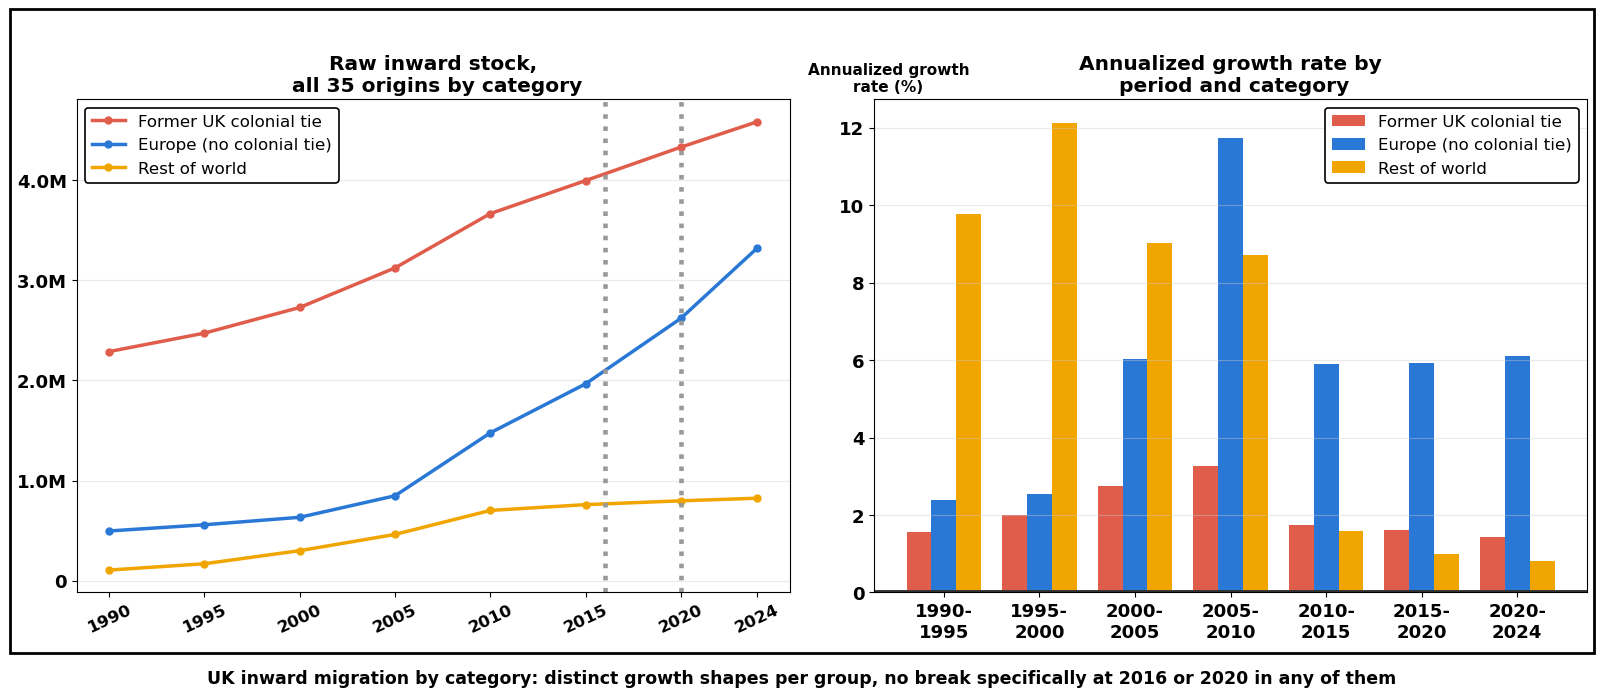

Saved: chart/part3_all_categories_growth.png


In [56]:
def add_figure_frame(fig, linewidth=2, edgecolor='black', margin=0.005):
    """Draws a rectangular border around the entire figure (outside all subplots)."""
    from matplotlib.patches import Rectangle
    rect = Rectangle(
        (margin, margin), 1 - 2 * margin, 1 - 2 * margin,
        transform=fig.transFigure,
        fill=False,
        edgecolor=edgecolor,
        linewidth=linewidth,
        clip_on=False,
    )
    fig.add_artist(rect)

# ---- knobs you can tune ----
YTICK_LABELSIZE_1 = 13   # ax1 (line chart)
YTICK_LABELSIZE_2 = 13   # ax2 (bar chart)
FRAME_COLOR = 'black'
FRAME_LINEWIDTH = 2
GRID_COLOR = '#cccccc'   # light grid, standard for a white background
LEGEND_FACECOLOR = 'white'
LEGEND_EDGECOLOR = 'black'
LEGEND_LINEWIDTH = 1.2

# lighter red for 'colony' -- copied so the original CAT_COLORS dict (used elsewhere) stays untouched
PLOT_CAT_COLORS = dict(CAT_COLORS)
PLOT_CAT_COLORS['colony'] = '#e05d4c'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))

for cat in ['colony', 'europe', 'rest']:
    ax1.plot(YEARS, category_totals_df[cat], color=PLOT_CAT_COLORS[cat], linewidth=2.5, marker='o', markersize=5,
              label=CAT_LABELS[cat])
ax1.axvline(2016, color='#999999', linestyle=':', linewidth=3.3)
ax1.axvline(2020, color='#999999', linestyle=':', linewidth=3.3)
ax1.yaxis.set_major_formatter(FuncFormatter(k_m_formatter))
ax1.set_xticks(YEARS); ax1.set_xticklabels(YEARS, rotation=25, fontsize=12, fontweight='bold')

# manual y-tick size + bold, independent per axis
ax1.tick_params(axis='y', labelsize=YTICK_LABELSIZE_1)
plt.setp(ax1.get_yticklabels(), fontweight='bold')

ax1.grid(axis='y', alpha=0.4, color=GRID_COLOR)

legend1 = ax1.legend(fontsize=12, loc='upper left',
                      framealpha=1, frameon=True, facecolor=LEGEND_FACECOLOR, edgecolor=LEGEND_EDGECOLOR)
legend1.get_frame().set_linewidth(LEGEND_LINEWIDTH)

ax1.set_title('Raw inward stock,\n all 35 origins by category', fontsize=14.5, fontweight='bold')

x = range(len(periods))
width = 0.26
for i, cat in enumerate(['colony', 'europe', 'rest']):
    offset = (i - 1) * width
    ax2.bar([xi + offset for xi in x], category_growth_df[cat], width=width, color=PLOT_CAT_COLORS[cat], label=CAT_LABELS[cat])
ax2.set_xticks(list(x))
ax2.set_xticklabels([f'{y1}-\n{y2}' for y1, y2 in periods], fontsize=13 , fontweight='bold')
ax2.set_ylabel('Annualized growth\nrate (%)', rotation=0, fontsize=11, fontweight='bold')
ax2.yaxis.set_label_coords(0.02, 1.01)

# manual y-tick size + bold, independent per axis
ax2.tick_params(axis='y', labelsize=YTICK_LABELSIZE_2)
plt.setp(ax2.get_yticklabels(), fontweight='bold')

ax2.axhline(0, color='#333333', linewidth=2.8)
ax2.grid(axis='y', alpha=0.4, color=GRID_COLOR)

legend2 = ax2.legend(fontsize=12, loc='upper right',
                      framealpha=1, frameon=True, facecolor=LEGEND_FACECOLOR, edgecolor=LEGEND_EDGECOLOR)
legend2.get_frame().set_linewidth(LEGEND_LINEWIDTH)

ax2.set_title('Annualized growth rate by\n period and category', fontsize=14.5, fontweight='bold')

fig.suptitle('UK inward migration by category: distinct growth shapes per group, no break specifically at 2016 or 2020 in any of them',
             fontsize=12.5, fontweight='bold',y=-0.02)

plt.tight_layout()

# frame around the whole figure, drawn after tight_layout so it isn't shrunk by it
add_figure_frame(fig, linewidth=FRAME_LINEWIDTH, edgecolor=FRAME_COLOR)

fig.savefig('chart/part3_all_categories_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart/part3_all_categories_growth.png")

**Finding: each category has a distinct growth shape, and none break at 2016 or 2020.**

- **Colonial-tie**: slow and steady throughout -- peaks modestly at 3.3%/yr (2005-2010),
  then gently decelerates to 1.4%/yr (2020-2024). A smooth decline, not a break.
- **Europe**: sharp peak of 11.7%/yr exactly during the 2005-2010 EU-accession wave, then
  **flatlines at roughly 6%/year for three consecutive periods in a row** --
  2010-2015, 2015-2020, and 2020-2024 -- spanning both the referendum and the transition
  period's end without visibly moving (5.9%, 5.9%, 6.1%). If ending free movement in 2020
  had a meaningfully large effect on EU inward migration, the last bar would be expected
  to drop below the two before it; instead it is essentially flat, if anything marginally
  higher.
- **Rest of world**: the opposite trajectory -- highest growth of the three in the 1990s
  (9.8-12.1%/yr), then a steady collapse toward near-zero (0.8%/yr by 2020-2024), with
  the largest single drop occurring between 2005-2010 and 2010-2015 -- years before the
  referendum.

Taken together with the accession-country test above, this is the most direct evidence
in the notebook against a Brexit-specific break in UK inward migration at this data
resolution: three structurally different groups, three different growth trajectories,
and none of them show a distinguishable kink at either reference point.

---
## Limitations (carried forward from scoping, restated for the record)

- **Country-of-birth, not citizenship** — this dataset cannot distinguish "who counts as
  British" in a legal sense; a real limitation for a Brexit-adjacent piece specifically,
  and the Poland/ONS comparison above shows this is not just an abstract caveat.
- **5-year snapshots** — cannot resolve fine-grained timing (e.g. referendum-month
  spikes); only broad multi-year movement is visible, which is itself part of why no
  sharp 2016/2020 break should be expected to show up even if one existed at finer
  resolution.
- **COVID/Brexit remain structurally confounded at the 2020 snapshot** — the absence of
  a visible break argues against a *large* combined effect, but cannot rule out smaller
  effects the snapshot structure isn't equipped to detect.
- **Eight destinations excluded for data-quality reasons** — Malta, Bangladesh, Cyprus,
  and Thailand (one statistical signature between them, though Thailand's specific
  pattern differs from the other three); UAE, Kuwait, Qatar, and Bahrain (a second
  signature, confirming Piece 1's Gulf-states finding for this corridor specifically).
  Isle of Man and British Virgin Islands excluded from the destination bar chart as
  untested (small sample), not because they failed a check. A further eight Middle East
  countries (Saudi Arabia, Oman, Jordan, Lebanon, Iraq, Iran, Yemen, Syria) return no
  UK-origin data at all — a coverage gap, not an exclusion.
- **UK's inward coverage is only 35 reported origin countries** — the "top 30 inward"
  chart is close to the entire UN-reported picture for this destination, not a curated
  slice. Only 3 of the 10 EU-accession (A8/A2) countries appear at all for this
  destination, for the same reason.
- All findings above are **descriptive/correlational only** — no causal claim about
  Brexit is made or implied anywhere in this notebook.